# Codificação Categórica na Prática
## Problema Modelo: Previsão de Gasto Mensal de Clientes (E-Commerce)

Este notebook demonstra, de forma experimental e comparativa, as principais
técnicas de codificação de variáveis categóricas. Cada experimento foi
projetado para revelar o comportamento específico de um *encoding* — seus
pontos fortes, suas limitações e as condições em que funciona bem ou mal.

### Estrutura

```
1. Importações e configuração
2. Geração dos dados
3. Análise exploratória (EDA)
4. Funções de pré-processamento (uma por encoding)
5. Funções de modelagem e avaliação
6. Experimentos
   6.0  Linha de base (baseline)
   6.1  Label Encoding
   6.2  One-Hot Encoding + Dummy Variable Trap + handle_unknown
   6.3  Ordinal Encoding
   6.4  Frequency Encoding
   6.5  Target Encoding (com e sem vazamento; curva de suavização)
   6.6  Binary Encoding
   6.7  Embeddings (PyTorch)
7. Resultados consolidados
8. Conclusão e guia de decisão
```

| Encoding   | Cardinalidade  | Ordem natural? | Risco principal            |
|------------|----------------|----------------|----------------------------|
| Label      | Qualquer       | Não            | Impõe ordem falsa          |
| One-Hot    | Baixa (< 20)   | Não            | Explosão dimensional       |
| Ordinal    | Qualquer       | Sim            | Exige mapeamento correto   |
| Frequency  | Qualquer       | Não            | Colisão de frequências     |
| Target     | Média / Alta   | Não            | Vazamento de dados         |
| Binary     | Média (20–100) | Não            | Bits sem semântica         |
| Embeddings | Alta (> 50)    | Não            | Requer dados suficientes   |


## 1. Importações e Configuração


In [25]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.linear_model    import Ridge
from sklearn.ensemble        import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.preprocessing   import (LabelEncoder, StandardScaler,
                                     MinMaxScaler, RobustScaler)
from sklearn.pipeline        import Pipeline
from sklearn.compose         import ColumnTransformer
from sklearn.decomposition   import PCA
from sklearn.metrics         import r2_score

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_OK = True
    print(f'PyTorch {torch.__version__} disponivel')
except ImportError:
    TORCH_OK = False
    print('PyTorch nao instalado — experimento de Embeddings usara proxy sklearn')

SEED = 42
np.random.seed(SEED)
plt.style.use('seaborn-v0_8-whitegrid')

# Paleta de cores — uma cor fixa por encoding (usada em todos os graficos)
COLORS = {
    'Baseline'  : '#95A5A6',
    'Label'     : '#E07B39',
    'One-Hot'   : '#5A9BD4',
    'Ordinal'   : '#2EAA6E',
    'Frequency' : '#8E44AD',
    'Target'    : '#C0392B',
    'Binary'    : '#1ABC9C',
}

NUM_COLS = ['meses_ativo', 'n_compras', 'ticket_medio']
print('Configuracao carregada.')

PyTorch 2.2.2 disponivel
Configuracao carregada.


## 2. Geração dos Dados

### Contexto do problema

O conjunto de dados simula o **cadastro e o histórico de compras de 2.000
clientes de uma plataforma de e-commerce**. O objetivo do modelo é prever o
`gasto_mensal` de cada cliente com base em suas características cadastrais e
comportamentais — um problema típico de segmentação de valor do cliente
(*Customer Lifetime Value*).

O dataset é inteiramente sintético, mas projetado com cuidado para que cada
variável categórica apresente um nível de cardinalidade diferente e um tipo
estrutural distinto (ordinal ou nominal). Dessa forma, cada encoding enfrenta
exatamente o cenário para o qual foi concebido, tornando as diferenças de
desempenho entre as técnicas claras e mensuráveis.

---

### Variáveis do dataset

O dataset contém **9 colunas**: 5 categóricas, 3 numéricas e 1 alvo.

#### Variáveis categóricas

| Variável         | Tipo    | Cardinalidade | Descrição                                                        |
|------------------|---------|---------------|------------------------------------------------------------------|
| `plano`          | Ordinal | 4             | Plano de assinatura do cliente: *básico*, *padrão*, *premium*, *enterprise*. Existe ordem real de valor — clientes *enterprise* gastam em média 4× mais que clientes *básico*. |
| `satisfacao`     | Ordinal | 5             | Nível de satisfação declarado: de *muito\_baixa* a *muito\_alta*. Clientes mais satisfeitos tendem a gastar mais. |
| `canal`          | Nominal | 5             | Canal de aquisição do cliente: *orgânico*, *pago*, *indicação*, *social*, *e-mail*. Não há hierarquia entre os canais — apenas diferenças de perfil de gasto. |
| `categoria_fav`  | Nominal | 15            | Categoria de produto preferida pelo cliente (ex.: eletrônicos, moda, games). Cardinalidade média — cada categoria tem um multiplicador de gasto distinto. |
| `cidade`         | Nominal | 60            | Cidade de origem do cliente. Alta cardinalidade com distribuição de frequência desigual (algumas cidades concentram muitos clientes; outras, poucos). O multiplicador de gasto por cidade é gerado aleatoriamente a partir de uma distribuição log-normal. |

#### Variáveis numéricas

| Variável       | Descrição                                                                 |
|----------------|---------------------------------------------------------------------------|
| `meses_ativo`  | Há quantos meses o cliente está ativo na plataforma (1 a 72 meses).      |
| `n_compras`    | Número de compras realizadas no período (distribuição de Poisson, média 8).|
| `ticket_medio` | Valor médio por compra em reais (distribuição log-normal, entre R$ 20 e R$ 800). |

#### Variável alvo

| Variável       | Descrição                                                                 |
|----------------|---------------------------------------------------------------------------|
| `gasto_mensal` | Gasto mensal estimado do cliente em reais. Limitado ao intervalo [50, 15.000]. Em todos os modelos, utilizamos `log1p(gasto_mensal)` como alvo para estabilizar a variância. |

---

### Como o alvo é gerado

O `gasto_mensal` é calculado como o produto de uma **base numérica** e de
**multiplicadores categóricos independentes**:

```
gasto = (200 + n_compras × ticket_medio × 0,15 + meses_ativo × 4,5)
        × mult_plano
        × mult_satisfacao
        × mult_canal
        × mult_categoria_fav
        × mult_cidade
        × exp(ruído)
```

Cada multiplicador foi definido manualmente para refletir um efeito plausível:

- **`mult_plano`:** varia de 0,60 (*básico*) a 2,40 (*enterprise*) — a maior
  fonte de variação no dataset, com relação monotônica perfeita com a hierarquia
  do plano. Isso garante que o Ordinal Encoding correto seja recompensado.
- **`mult_satisfacao`:** varia de 0,50 (*muito\_baixa*) a 1,50 (*muito\_alta*)
  — também monotônico, testando o segundo encoding ordinal.
- **`mult_canal`:** varia de 0,80 (*social*) a 1,15 (*indicação*) — efeitos
  pequenos e sem ordem natural, cenário ideal para One-Hot Encoding.
- **`mult_categoria_fav`:** varia de 0,70 (*livros*) a 1,40 (*eletrônicos*)
  — 15 categorias com impactos distintos, cardinalidade média ideal para
  Target Encoding e Frequency Encoding.
- **`mult_cidade`:** gerado aleatoriamente por uma distribuição log-normal —
  60 cidades com efeitos heterogêneos e distribuição de frequência desigual
  (Dirichlet), o cenário mais desafiador para encodings e o que mais diferencia
  Binary Encoding, Target Encoding e Embeddings.
- **`exp(ruído)`:** ruído multiplicativo log-normal com desvio padrão de 0,12,
  representando fatores não observados (sazonalidade, promoções, comportamento
  individual).

Essa estrutura garante que **todas as variáveis categóricas têm impacto real
e detectável** sobre o alvo, de modo que a qualidade do encoding se traduz
diretamente em ganho de R².


In [26]:
N = 2000

# Variaveis ordinais
PLANOS     = ['basico', 'padrao', 'premium', 'enterprise']
PLANO_MULT = {'basico': 0.6, 'padrao': 1.0, 'premium': 1.5, 'enterprise': 2.4}
MAPA_PLANO = {'basico': 0, 'padrao': 1, 'premium': 2, 'enterprise': 3}

SATS       = ['muito_baixa', 'baixa', 'media', 'alta', 'muito_alta']
SAT_MULT   = {'muito_baixa': 0.5, 'baixa': 0.75, 'media': 1.0,
              'alta': 1.25, 'muito_alta': 1.5}
MAPA_SAT   = {'muito_baixa': 0, 'baixa': 1, 'media': 2, 'alta': 3, 'muito_alta': 4}

# Variaveis nominais
CANAIS     = ['organico', 'pago', 'indicacao', 'social', 'email']
CANAL_MULT = {'organico': 1.0, 'pago': 0.9, 'indicacao': 1.15,
              'social': 0.8, 'email': 1.05}

CATS = ['eletronicos','moda','casa','esportes','beleza',
        'livros','games','bebes','pet','automotivo',
        'alimentos','viagem','saude','industria','escritorio']
CAT_MULT = dict(zip(CATS,
    [1.4, 1.0, 0.9, 1.1, 0.8, 0.7, 1.3, 1.0, 0.95,
     1.2, 0.75, 1.35, 1.05, 1.1, 0.85]))

N_CIDADES     = 60
CIDADES       = [f'cidade_{i:02d}' for i in range(N_CIDADES)]
CIDADE_MULT_V = np.random.lognormal(0, 0.35, N_CIDADES)
CIDADE_MULT   = dict(zip(CIDADES, CIDADE_MULT_V))
CIDADE_FREQ   = np.random.dirichlet(np.ones(N_CIDADES) * 0.6)

# Amostragem
plano_col  = np.random.choice(PLANOS, N, p=[0.30, 0.35, 0.25, 0.10])
sat_col    = np.random.choice(SATS,   N, p=[0.08, 0.17, 0.35, 0.25, 0.15])
canal_col  = np.random.choice(CANAIS, N, p=[0.25, 0.20, 0.20, 0.20, 0.15])
probs_cat  = np.array([0.12,0.10,0.09,0.08,0.08,0.07,0.07,
                        0.06,0.06,0.05,0.05,0.05,0.04,0.04,0.04])
cat_col    = np.random.choice(CATS,    N, p=probs_cat / probs_cat.sum())
cidade_col = np.random.choice(CIDADES, N, p=CIDADE_FREQ)

meses_ativo  = np.random.exponential(18, N).clip(1, 72).astype(int)
n_compras    = np.random.poisson(8, N).clip(0, 60)
ticket_medio = np.random.lognormal(4.5, 0.5, N).clip(20, 800)

noise = np.random.normal(0, 0.12, N)
gasto = (
    200 + n_compras * ticket_medio * 0.15 + meses_ativo * 4.5
) * np.array([PLANO_MULT[p]  for p in plano_col])   * np.array([SAT_MULT[s]    for s in sat_col])   * np.array([CANAL_MULT[c]  for c in canal_col])   * np.array([CAT_MULT[c]    for c in cat_col])   * np.array([CIDADE_MULT[c] for c in cidade_col])   * np.exp(noise)

df = pd.DataFrame({
    'plano'        : plano_col,
    'satisfacao'   : sat_col,
    'canal'        : canal_col,
    'categoria_fav': cat_col,
    'cidade'       : cidade_col,
    'meses_ativo'  : meses_ativo,
    'n_compras'    : n_compras,
    'ticket_medio' : ticket_medio.round(2),
    'gasto_mensal' : gasto.clip(50, 15000).round(2),
})

y = np.log1p(df['gasto_mensal'])

print(f'Dataset: {df.shape[0]} clientes x {df.shape[1]} colunas')
print()
print('Cardinalidade das variaveis categoricas:')
for c in ['plano','satisfacao','canal','categoria_fav','cidade']:
    print(f'  {c:<18}: {df[c].nunique():>3} categorias')
df.head()

Dataset: 2000 clientes x 9 colunas

Cardinalidade das variaveis categoricas:
  plano             :   4 categorias
  satisfacao        :   5 categorias
  canal             :   5 categorias
  categoria_fav     :  15 categorias
  cidade            :  53 categorias


,plano,satisfacao,canal,categoria_fav,cidade,meses_ativo,n_compras,ticket_medio,gasto_mensal
0,basico,baixa,email,moda,cidade_05,60,7,59.18,184.14
1,padrao,baixa,social,esportes,cidade_49,5,10,78.95,142.29
2,basico,muito_baixa,indicacao,eletronicos,cidade_16,1,5,122.49,85.93
3,basico,media,social,bebes,cidade_29,14,11,63.31,139.23
4,enterprise,media,pago,moda,cidade_17,22,7,124.62,1050.86


## 3. Análise Exploratória (EDA)

**Objetivo:** verificar que cada variável categórica possui impacto real e
distinguível sobre o gasto mensal. Esse é o pré-requisito para que as
diferenças entre encodings sejam mensuráveis: se a variável não prediz nada,
nenhum encoding será capaz de ajudar.

**Racional:** plotamos a mediana do gasto por categoria, respeitando a ordem
correta quando a variável é ordinal. Uma tendência monotônica em `plano` e
`satisfacao` confirma que o mapeamento ordinal é válido para essas variáveis.


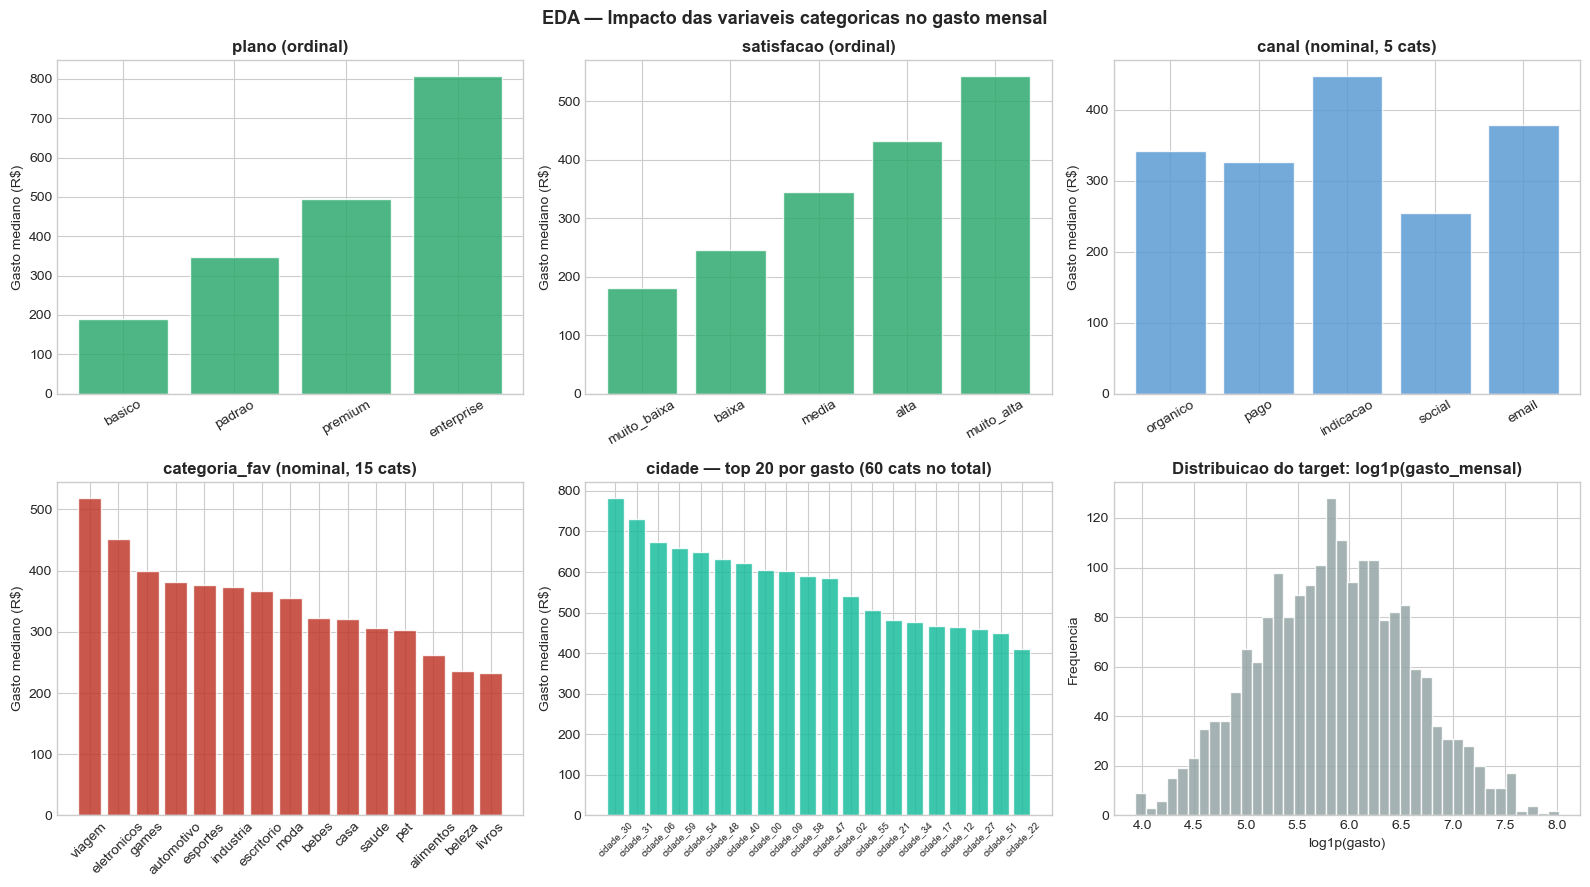

Observacoes:
  - plano e satisfacao mostram tendencia monotonica -> Ordinal Encoding e valido.
  - cidade tem enorme variacao de gasto -> encoding de alta card. e necessario.
  - target em log tem distribuicao aproximadamente normal -> bom para Ridge.


In [27]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('EDA — Impacto das variaveis categoricas no gasto mensal',
             fontsize=13, fontweight='bold')

# Variaveis ordinais com ordem definida
for ax, (col, ordem) in zip(axes[0], [
    ('plano',      PLANOS),
    ('satisfacao', SATS),
]):
    medias = df.groupby(col)['gasto_mensal'].median().reindex(ordem)
    ax.bar(medias.index, medias.values,
           color=COLORS['Ordinal'], edgecolor='white', alpha=0.85)
    ax.set_title(f'{col} (ordinal)', fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylabel('Gasto mediano (R$)')

# Canal (nominal, baixa card.)
medias_canal = df.groupby('canal')['gasto_mensal'].median().reindex(CANAIS)
axes[0, 2].bar(medias_canal.index, medias_canal.values,
               color=COLORS['One-Hot'], edgecolor='white', alpha=0.85)
axes[0, 2].set_title('canal (nominal, 5 cats)', fontweight='bold')
axes[0, 2].tick_params(axis='x', rotation=30)
axes[0, 2].set_ylabel('Gasto mediano (R$)')

# Categoria (nominal, media card.)
medias_cat = (df.groupby('categoria_fav')['gasto_mensal']
              .median().sort_values(ascending=False))
axes[1, 0].bar(medias_cat.index, medias_cat.values,
               color=COLORS['Target'], edgecolor='white', alpha=0.85)
axes[1, 0].set_title('categoria_fav (nominal, 15 cats)', fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].set_ylabel('Gasto mediano (R$)')

# Cidade — top 20 por gasto (nominal, alta card.)
medias_cid = (df.groupby('cidade')['gasto_mensal']
              .median().sort_values(ascending=False).head(20))
axes[1, 1].bar(medias_cid.index, medias_cid.values,
               color=COLORS['Binary'], edgecolor='white', alpha=0.85)
axes[1, 1].set_title('cidade — top 20 por gasto (60 cats no total)',
                     fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45, labelsize=7)
axes[1, 1].set_ylabel('Gasto mediano (R$)')

# Distribuicao do target
axes[1, 2].hist(y, bins=40, color=COLORS['Baseline'], edgecolor='white', alpha=0.85)
axes[1, 2].set_title('Distribuicao do target: log1p(gasto_mensal)',
                     fontweight='bold')
axes[1, 2].set_xlabel('log1p(gasto)'); axes[1, 2].set_ylabel('Frequencia')

plt.tight_layout()
plt.show()

print('Observacoes:')
print('  - plano e satisfacao mostram tendencia monotonica -> Ordinal Encoding e valido.')
print('  - cidade tem enorme variacao de gasto -> encoding de alta card. e necessario.')
print('  - target em log tem distribuicao aproximadamente normal -> bom para Ridge.')

## 4. Funções de Pré-processamento

Cada função recebe o DataFrame original e devolve uma matriz X pronta para
modelagem. **Nenhum experimento é executado nesta seção** — apenas as
transformações são declaradas.

Regras de implementação adotadas:

- Nenhuma função chama `display()` internamente. A visualização dos DataFrames
  resultantes é feita nas células de experimento, onde se controla o que exibir.
- As funções não modificam o DataFrame original (operam em cópias).
- O conjunto de atributos numéricos e ordinais (`_base_num_ord`) é sempre
  incluído como ponto de partida, garantindo comparabilidade entre os experimentos.


In [28]:
# Utilitario: colunas base (numericas + ordinais com mapeamento correto)
def _base_num_ord(df_in):
    """
    Retorna DataFrame com features numericas + ordinais mapeadas corretamente.
    Serve como ponto de partida para todos os encodings das variaveis nominais.
    O mapeamento ordinal reflete a ordem real das categorias, nao a
    ordem alfabetica que o LabelEncoder usaria automaticamente.
    """
    X = df_in[NUM_COLS].copy().reset_index(drop=True)
    X['plano_ord']      = df_in['plano'].map(MAPA_PLANO).values
    X['satisfacao_ord'] = df_in['satisfacao'].map(MAPA_SAT).values
    return X


# ─────────────────────────────────────────────────────────────────────
# 4.1  Label Encoding
#
# Passos:
#   1. Para cada coluna categorica, instanciar um LabelEncoder().
#   2. Chamar fit_transform(coluna) — o encoder aprende as categorias
#      presentes e as converte para inteiros em ordem ALFABETICA.
#   3. Adicionar a coluna resultante ao DataFrame de features.
#
# Resultado: cada categoria vira um inteiro unico (0, 1, 2, ...).
# Atencao: a ordem alfabetica raramente reflete ordem de negocio.
# ─────────────────────────────────────────────────────────────────────
def encode_label(df_in):
    """
    Mapeia cada categoria a um inteiro pela ordem alfabetica (arbitraria).
    Impoe ordem e distancias falsas — problematico para modelos lineares.
    """
    X = df_in[NUM_COLS].copy().reset_index(drop=True)
    for col in ['plano', 'satisfacao', 'canal', 'categoria_fav', 'cidade']:
        # Passo 1-2: instanciar e ajustar o encoder na coluna
        X[col + '_le'] = LabelEncoder().fit_transform(df_in[col])
        # Passo 3: a coluna resultante contem inteiros 0..k-1
    return X.astype(float)


# ─────────────────────────────────────────────────────────────────────
# 4.2  One-Hot Encoding
#
# Passos:
#   1. Instanciar OneHotEncoder com os parametros desejados:
#      - drop='first'          evita a Dummy Variable Trap
#      - sparse_output=False   retorna array denso (mais facil de manusear)
#      - handle_unknown=...    define o comportamento em producao
#   2. Chamar fit_transform(df[cat_cols]) — para cada categoria de cada
#      coluna, o encoder cria uma coluna binaria (0 ou 1).
#   3. Nomear as novas colunas com get_feature_names_out().
#   4. Concatenar as colunas binarias ao DataFrame base.
#
# Resultado: k categorias → k-1 colunas (com drop='first').
# ─────────────────────────────────────────────────────────────────────
def encode_onehot(df_in, cat_cols, drop_first=True, handle_unknown='error'):
    """
    Cada categoria vira uma coluna binaria independente.

    Parametros
    ----------
    cat_cols       : colunas nominais a aplicar OHE
    drop_first     : se True, remove a primeira coluna (evita Dummy Trap)
    handle_unknown : 'error' (padrao sklearn) ou 'ignore' (para producao)
    """
    from sklearn.preprocessing import OneHotEncoder

    # Passo 1: configurar o encoder
    X = _base_num_ord(df_in)
    ohe = OneHotEncoder(drop='first' if drop_first else None,
                        sparse_output=False,
                        handle_unknown=handle_unknown)

    # Passo 2: ajustar e transformar — cada categoria vira uma coluna binaria
    arr = ohe.fit_transform(df_in[cat_cols])

    # Passo 3: recuperar os nomes gerados automaticamente (ex: canal_pago)
    cols = ohe.get_feature_names_out(cat_cols)

    # Passo 4: montar DataFrame e concatenar ao base
    dummies = pd.DataFrame(arr, columns=cols)
    return pd.concat([X, dummies], axis=1).astype(float)


# ─────────────────────────────────────────────────────────────────────
# 4.3  Ordinal Encoding
#
# Passos:
#   1. Definir (externamente) um dicionario {categoria: inteiro} que
#      reflita a ordem REAL de negocio — nunca confiar na ordem alfabetica.
#   2. Aplicar Series.map(mapa_dict) para substituir cada categoria
#      pelo inteiro correspondente.
#   3. Tratar eventuais NaN (categorias nao mapeadas).
#
# Resultado: 1 coluna numerica com ordem significativa.
# O parametro fallback_le=True simula o erro de usar LabelEncoder
# em variavel ordinal — util para a comparacao didatica.
# ─────────────────────────────────────────────────────────────────────
def encode_ordinal(df_in, fallback_le=False):
    """
    Monta a matriz de features codificando plano e satisfacao como ordinais.

    fallback_le=False (correto) : usa o mapeamento real definido em MAPA_PLANO
                                  e MAPA_SAT — a ordem reflete o negocio.
    fallback_le=True  (errado)  : usa LabelEncoder, que atribui inteiros por
                                  ordem ALFABETICA — a ordem e arbitraria.

    Para isolar o efeito do encoding ordinal, esta funcao constroi as features
    a partir das colunas numericas brutas (sem passar por _base_num_ord), de
    modo que plano e satisfacao entrem exclusivamente pelo encoding comparado.
    """
    # Ponto de partida: apenas features numericas — sem ordinais pre-mapeados
    X = df_in[NUM_COLS].copy().reset_index(drop=True)

    for col_name, mapa_dict in [('plano', MAPA_PLANO), ('satisfacao', MAPA_SAT)]:
        if fallback_le:
            # Passo 2 (errado): ordem alfabetica arbitraria
            X[col_name + '_enc'] = LabelEncoder().fit_transform(df_in[col_name])
        else:
            # Passo 1-2 (correto): mapa com a ordem real de negocio
            X[col_name + '_enc'] = df_in[col_name].map(mapa_dict).values

    # Variaveis nominais restantes: OHE para canal/categoria, Label para cidade
    dummies = pd.get_dummies(
        df_in[['canal', 'categoria_fav']].reset_index(drop=True), drop_first=True
    )
    X = pd.concat([X, dummies], axis=1)
    X['cidade_le'] = LabelEncoder().fit_transform(df_in['cidade'])
    return X.astype(float)


# ─────────────────────────────────────────────────────────────────────
# 4.4  Frequency Encoding
#
# Passos:
#   1. Calcular a frequencia relativa de cada categoria no conjunto de
#      TREINO: value_counts(normalize=True) retorna a proporcao de
#      cada valor (soma = 1.0).
#   2. Armazenar o mapeamento {categoria: frequencia} para reutilizacao
#      em dados novos (sem recalcular — evita leakage).
#   3. Substituir cada ocorrencia da categoria pelo valor de frequencia
#      via Series.map(freq_map).
#   4. Para categorias nao vistas (producao), preencher com 1/k como
#      valor neutro.
#
# Resultado: 1 coluna numerica por variavel, sem leakage.
# ─────────────────────────────────────────────────────────────────────
def _encode_frequency(df_in, col, freq_map=None):
    """Substitui cada categoria pela sua frequencia relativa no dataset."""

    if freq_map is None:
        # Passo 1: calcular frequencias relativas apenas no conjunto atual
        freq_map = df_in[col].value_counts(normalize=True).to_dict()
        # Passo 2: freq_map e retornado para ser reutilizado em dados de teste

    # Passo 3-4: mapear e preencher categorias desconhecidas com 1/k
    return df_in[col].map(freq_map).fillna(1 / df_in[col].nunique()), freq_map


def build_frequency_features(df_in):
    """Monta X com Frequency Encoding para categoria e cidade."""
    X = _base_num_ord(df_in)
    dummies_canal = pd.get_dummies(
        df_in[['canal']].reset_index(drop=True), drop_first=True
    )
    X = pd.concat([X, dummies_canal], axis=1)
    for col in ['categoria_fav', 'cidade']:
        freq_vals, _ = _encode_frequency(df_in.reset_index(drop=True), col)
        X[col + '_freq'] = freq_vals.values
    return X.astype(float)


# ─────────────────────────────────────────────────────────────────────
# 4.5  Target Encoding
#
# Passos (versao correta — OOF):
#   1. Dividir os dados em n_splits folds (KFold).
#   2. Para cada fold, calcular a media do target SOMENTE nas amostras
#      de treino daquele fold — nunca usando as amostras de validacao.
#   3. Aplicar suavizacao (smoothing) para estabilizar grupos com poucas
#      amostras:
#          enc(j) = (n_j * media_j + m * media_global) / (n_j + m)
#      Grupos pequenos ficam mais proximos da media global.
#   4. Atribuir o valor suavizado a cada amostra do fold de validacao.
#   5. Categorias nao vistas recebem a media global como fallback.
#
# Versao errada (target_encode_naive): calcula a media usando treino +
# teste juntos — cada amostra "ve" o proprio target → leakage.
# ─────────────────────────────────────────────────────────────────────
def target_encode_oof(df_in, col, target_series, smoothing=10, n_splits=5):
    """
    Target Encoding out-of-fold com suavizacao.
    A media do target e calculada SOMENTE nos folds de treino de cada
    iteracao do KFold, eliminando data leakage.

    Formula de suavizacao:
        enc(j) = (n_j * media_j + m * media_global) / (n_j + m)
    onde m e o parametro de suavizacao.
    """
    # Passo 5: media global usada como fallback para categorias novas
    global_mean = target_series.mean()
    encoded     = np.full(len(df_in), global_mean, dtype=float)

    # Passo 1: definir os folds
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    for tr_idx, va_idx in kf.split(df_in):
        tr_y   = target_series.iloc[tr_idx]
        tr_col = df_in[col].iloc[tr_idx]
        va_col = df_in[col].iloc[va_idx]

        # Passo 2: estatisticas calculadas APENAS com o fold de treino
        stats = tr_y.groupby(tr_col).agg(['mean', 'count'])

        # Passo 3: aplicar suavizacao — grupos pequenos regridem a media global
        stats['smooth'] = (
            (stats['mean'] * stats['count'] + global_mean * smoothing)
            / (stats['count'] + smoothing)
        )

        # Passo 4: atribuir o valor suavizado ao fold de validacao
        encoded[va_idx] = va_col.map(stats['smooth']).fillna(global_mean).values

    return encoded


def target_encode_naive(df_tr, df_te, col, target_col):
    """
    Target Encoding COM leakage — versao errada, usada para fins didaticos.
    Calcula a media usando treino + teste misturados.
    """
    # ERRADO: o mapeamento e calculado com treino + teste juntos.
    # Cada amostra do treino contribui para a media que sera usada
    # como feature dela propria — o modelo "ve" o proprio target.
    full_df = pd.concat([df_tr, df_te])
    mapping = full_df.groupby(col)[target_col].mean()
    return df_tr[col].map(mapping), df_te[col].map(mapping)


def build_target_features(df_in, y_series):
    """Monta X com Target Encoding OOF para categoria e cidade."""
    X = _base_num_ord(df_in)
    dummies_canal = pd.get_dummies(
        df_in[['canal']].reset_index(drop=True), drop_first=True
    )
    X = pd.concat([X, dummies_canal], axis=1)
    df_ri = df_in.reset_index(drop=True)
    y_ri  = y_series.reset_index(drop=True)
    for col in ['categoria_fav', 'cidade']:
        X[col + '_te'] = target_encode_oof(df_ri, col, y_ri)
    return X.astype(float)


# ─────────────────────────────────────────────────────────────────────
# 4.6  Binary Encoding
#
# Passos:
#   1. Aplicar Label Encoding para obter um inteiro por categoria
#      (0, 1, 2, ..., k-1).
#   2. Calcular o numero de bits necessarios: ceil(log2(k)).
#   3. Converter cada inteiro para sua representacao binaria com
#      exatamente n_bits digitos (zeros a esquerda quando necessario).
#   4. Cada bit vira uma coluna separada no DataFrame final.
#
# Resultado: ceil(log2(k)) colunas ao inves de k-1 (OHE) ou 1 (Label).
# Exemplo: 60 cidades → ceil(log2(60)) = 6 colunas (vs 59 no OHE).
# ─────────────────────────────────────────────────────────────────────
def binary_encode_col(series):
    """Label Encoding -> representacao binaria (ceil(log2(k)) colunas)."""

    # Passo 1: converter categorias para inteiros (0..k-1)
    labels = LabelEncoder().fit_transform(series)

    # Passo 2: numero de bits para representar k categorias distintas
    n_bits = max(1, int(np.ceil(np.log2(series.nunique() + 1))))

    # Passo 3: converter cada inteiro para string binaria de n_bits digitos
    # Passo 4: cada digito binario vira uma coluna separada
    bits = np.array([[int(b) for b in format(x, f'0{n_bits}b')]
                      for x in labels])

    return pd.DataFrame(bits,
                        columns=[f'{series.name}_b{i}' for i in range(n_bits)])


def build_binary_features(df_in):
    """Monta X com Binary Encoding para categoria e cidade."""
    X = _base_num_ord(df_in)
    dummies_canal = pd.get_dummies(
        df_in[['canal']].reset_index(drop=True), drop_first=True
    )
    X = pd.concat([
        X,
        dummies_canal,
        binary_encode_col(df_in['categoria_fav'].reset_index(drop=True)),
        binary_encode_col(df_in['cidade'].reset_index(drop=True)),
    ], axis=1)
    return X.astype(float)


print('Funcoes de preprocessamento definidas.')


Funcoes de preprocessamento definidas.


## 5. Funções de Modelagem e Avaliação

Todas as comparações utilizam o mesmo protocolo:

- **Ridge com StandardScaler:** sensível à escala e à ordem das *features*,
  ideal para expor erros de codificação.
- **Random Forest:** baseado em limiares (*thresholds*), imune à magnitude —
  serve de controle para demonstrar que certos encodings prejudicam apenas
  modelos lineares.
- **Métrica:** R² médio em validação cruzada com 5 partições (KFold com embaralhamento).
- **Os resultados são acumulados em `RESULTADOS`** para a comparação final na Seção 9.


In [29]:
RESULTADOS = {}


def avaliar_sklearn(X, y, label, modelo='ridge', alpha=10.0):
    """
    Avalia um conjunto de features com CV 5-fold.

    Parametros
    ----------
    X      : DataFrame de features
    y      : Series com o target (log1p do gasto)
    label  : nome do experimento (chave em RESULTADOS)
    modelo : 'ridge' ou 'rf'
    alpha  : regularizacao do Ridge

    Retorna
    -------
    r2_mean : R² medio dos 5 folds
    """
    if modelo == 'ridge':
        pipe = Pipeline([('sc', StandardScaler()),
                         ('m',  Ridge(alpha=alpha))])
    else:
        pipe = Pipeline([('m', RandomForestRegressor(
            n_estimators=100, max_depth=8, random_state=SEED))])

    cv  = KFold(n_splits=5, shuffle=True, random_state=SEED)
    r2s = cross_val_score(pipe, X, y, cv=cv, scoring='r2')
    r2_mean = float(r2s.mean())
    RESULTADOS[label] = {
        'r2': r2_mean, 'std': float(r2s.std()),
        'modelo': modelo, 'n_features': X.shape[1]
    }
    return r2_mean


def avaliar_holdout(X_tr, X_te, y_tr, y_te, label, alpha=10.0):
    """
    Avalia em holdout 80/20 — usada exclusivamente para demonstrar leakage.
    Retorna R² no conjunto de teste.
    """
    pipe = Pipeline([('sc', StandardScaler()), ('m', Ridge(alpha=alpha))])
    pipe.fit(X_tr, y_tr)
    r2 = r2_score(y_te, pipe.predict(X_te))
    RESULTADOS[label] = {'r2': r2, 'std': None,
                          'modelo': 'ridge_holdout', 'n_features': X_tr.shape[1]}
    return r2


print('Funcoes de modelagem definidas.')

Funcoes de modelagem definidas.


In [30]:
if TORCH_OK:
    class EmbNet(nn.Module):
        """
        Rede neural com camadas de Embedding para variaveis categoricas.
        As categorias aprendem vetores densos que capturam similaridade.

        Arquitetura:
          Embedding(cidade)  [dim_cid]
          Embedding(cat_fav) [dim_cat]
          Concat(num, emb_cidade, emb_cat) -> FC(64) -> ReLU -> Dropout -> FC(1)
        """
        def __init__(self, n_cidades, n_cats, n_num, dim_cid=8, dim_cat=4):
            super().__init__()
            self.emb_cidade = nn.Embedding(n_cidades, dim_cid)
            self.emb_cat    = nn.Embedding(n_cats,    dim_cat)
            self.fc = nn.Sequential(
                nn.Linear(n_num + dim_cid + dim_cat, 64),
                nn.ReLU(),
                nn.Dropout(0.2),
                nn.Linear(64, 32),
                nn.ReLU(),
                nn.Linear(32, 1),
            )
        def forward(self, num_x, cidade_idx, cat_idx):
            ec = self.emb_cidade(cidade_idx)
            ek = self.emb_cat(cat_idx)
            return self.fc(torch.cat([num_x, ec, ek], dim=1)).squeeze(1)

    def avaliar_embnet(X_num_arr, X_cid_arr, X_cat_arr, y_arr,
                       n_cid, n_cat, label, dim_cid=8, dim_cat=4,
                       n_epochs=40, lr=3e-3):
        kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
        r2_scores = []; trained_model = None
        for tr, va in kf.split(X_num_arr):
            model = EmbNet(n_cid, n_cat, X_num_arr.shape[1], dim_cid, dim_cat)
            opt   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
            loss_fn = nn.MSELoss()
            ds = TensorDataset(
                torch.tensor(X_num_arr[tr], dtype=torch.float32),
                torch.tensor(X_cid_arr[tr], dtype=torch.long),
                torch.tensor(X_cat_arr[tr], dtype=torch.long),
                torch.tensor(y_arr[tr],     dtype=torch.float32),
            )
            dl = DataLoader(ds, batch_size=128, shuffle=True)
            model.train()
            for _ in range(n_epochs):
                for xn, xc, xk, yt in dl:
                    opt.zero_grad()
                    pred = model(xn, xc, xk)
                    loss_fn(pred, yt).backward()
                    opt.step()
            model.eval()
            with torch.no_grad():
                Xn_t = torch.tensor(X_num_arr[va], dtype=torch.float32)
                Xc_t = torch.tensor(X_cid_arr[va], dtype=torch.long)
                Xk_t = torch.tensor(X_cat_arr[va], dtype=torch.long)
                preds = model(Xn_t, Xc_t, Xk_t).numpy()
            r2_scores.append(r2_score(y_arr[va], preds))
            trained_model = model
        r2_mean = float(np.mean(r2_scores))
        RESULTADOS[label] = {'r2': r2_mean, 'std': float(np.std(r2_scores)),
                              'modelo': 'embnet', 'n_features': dim_cid + dim_cat}
        return r2_mean, trained_model

    print('EmbNet definida.')
else:
    print('EmbNet nao disponivel (PyTorch ausente).')

EmbNet definida.


## 6. Experimentos


### 6.0 Linha de Base — Apenas Atributos Numéricos

**Objetivo:** estabelecer o ponto de referência antes de qualquer codificação.
O modelo recebe somente as três variáveis numéricas brutas: `meses_ativo`,
`n_compras` e `ticket_medio`. Qualquer encoding que não supere esse R² não
agrega valor.

**Racional:** um R² baixo na linha de base confirma que as variáveis categóricas
carregam informação real que ainda não está disponível para o modelo.


In [31]:
print('=' * 60)
print('BASELINE — apenas features numericas brutas')
print('=' * 60)

X_baseline = df[NUM_COLS].copy()

r2_ridge = avaliar_sklearn(X_baseline, y, 'Baseline (Ridge)', modelo='ridge')
r2_rf    = avaliar_sklearn(X_baseline, y, 'Baseline (RF)',    modelo='rf')

print(f'  Ridge:        R² = {r2_ridge:.4f}')
print(f'  RandomForest: R² = {r2_rf:.4f}')
print(f'  Shape: {X_baseline.shape}')


BASELINE — apenas features numericas brutas
  Ridge:        R² = 0.1236
  RandomForest: R² = 0.0821
  Shape: (2000, 3)


**Conclusão:** os atributos numéricos sozinhos explicam uma parcela limitada da variação
no gasto mensal. A diferença em relação aos experimentos seguintes medirá exatamente o
quanto cada encoding contribui ao disponibilizar a informação categórica para o modelo.


### 6.1 Label Encoding

**Objetivo:** demonstrar como o Label Encoding impõe ordem e distâncias falsas
entre categorias nominais e por que isso prejudica modelos lineares, mas não
modelos de árvore.

**Racional:**

- O `LabelEncoder` atribui inteiros por ordem alfabética: `basico=0, enterprise=1,
  padrao=2, premium=3`. Essa ordem não reflete o poder de compra real
  (`basico < padrao < premium < enterprise`).
- O Ridge aprende um coeficiente que multiplica o inteiro — interpretando que
  `enterprise (1)` possui *menos poder* que `padrao (2)`, o que é falso.
- O Random Forest utiliza apenas limiares (`se valor <= 1.5`), sendo imune
  à magnitude: ele consegue isolar cada categoria com divisões suficientes.


LABEL ENCODING
Mapeamento alfabetico — ordem arbitraria
Shape: (2000, 8)

Mapeamento gerado pelo LabelEncoder para plano (alfabetico):
{'basico': 0, 'enterprise': 1, 'padrao': 2, 'premium': 3}

Mapeamento correto (ordem real de valor):
{'basico': 0, 'padrao': 1, 'premium': 2, 'enterprise': 3}


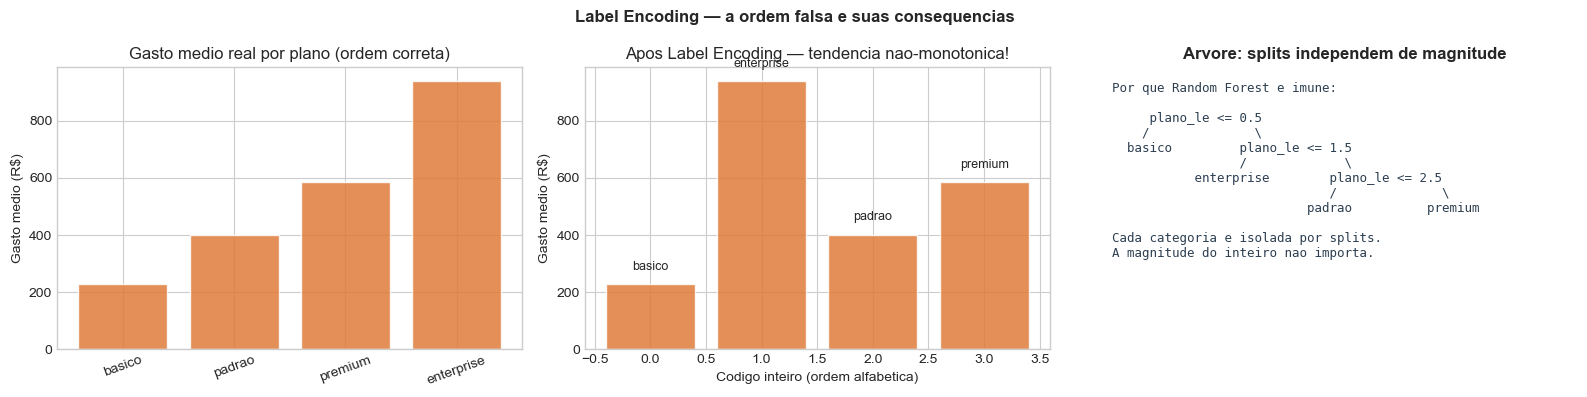

  Ridge:        R² = 0.3507
  RandomForest: R² = 0.6596


In [32]:
print('=' * 60)
print('LABEL ENCODING')
print('Mapeamento alfabetico — ordem arbitraria')
print('=' * 60)

X_label = encode_label(df)
print(f'Shape: {X_label.shape}')
print()
print('Mapeamento gerado pelo LabelEncoder para plano (alfabetico):')
le_plano = LabelEncoder().fit(df['plano'])
print(dict(zip(le_plano.classes_, le_plano.transform(le_plano.classes_))))
print()
print('Mapeamento correto (ordem real de valor):')
print(MAPA_PLANO)

# Visualizacao: tendencia real vs tendencia apos label encoding
df_tmp = df.copy()
df_tmp['plano_le'] = le_plano.transform(df['plano'])
le_classes = list(le_plano.classes_)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Label Encoding — a ordem falsa e suas consequencias', fontweight='bold')

medias_real = df.groupby('plano')['gasto_mensal'].mean().reindex(PLANOS)
axes[0].bar(medias_real.index, medias_real.values,
            color=COLORS['Label'], alpha=0.85, edgecolor='white')
axes[0].set_title('Gasto medio real por plano (ordem correta)')
axes[0].set_ylabel('Gasto medio (R$)')
axes[0].tick_params(axis='x', rotation=20)

medias_le = df_tmp.groupby('plano_le')['gasto_mensal'].mean()
for idx, val in medias_le.items():
    axes[1].bar(idx, val, color=COLORS['Label'], alpha=0.85, edgecolor='white')
    axes[1].text(idx, val + 50, le_classes[idx], ha='center', fontsize=9)
axes[1].set_title('Apos Label Encoding — tendencia nao-monotonica!')
axes[1].set_xlabel('Codigo inteiro (ordem alfabetica)')
axes[1].set_ylabel('Gasto medio (R$)')

axes[2].set_xlim(0, 4); axes[2].set_ylim(0, 4); axes[2].axis('off')
tree_text = (
    "Por que Random Forest e imune:\n\n"
    "     plano_le <= 0.5\n"
    "    /              \\\n"
    "  basico         plano_le <= 1.5\n"
    "                 /             \\\n"
    "           enterprise        plano_le <= 2.5\n"
    "                             /              \\\n"
    "                          padrao          premium\n\n"
    "Cada categoria e isolada por splits.\n"
    "A magnitude do inteiro nao importa."
)
axes[2].text(0.0, 3.8, tree_text, fontsize=9, va='top',
             fontfamily='monospace', color='#2C3E50')
axes[2].set_title('Arvore: splits independem de magnitude', fontweight='bold')

plt.tight_layout()
plt.show()

r2_l_r  = avaliar_sklearn(X_label, y, 'Label (Ridge)', modelo='ridge')
r2_l_rf = avaliar_sklearn(X_label, y, 'Label (RF)',    modelo='rf')
print(f'  Ridge:        R² = {r2_l_r:.4f}')
print(f'  RandomForest: R² = {r2_l_rf:.4f}')


**Conclusão:** Label Encoding em variáveis nominais prejudica severamente modelos
lineares, que interpretam os inteiros como magnitudes reais. O Random Forest é
imune porque suas decisões são baseadas em limiares binários, não em grandeza numérica.
A regra prática é clara: Label Encoding só é seguro em variáveis ordinais com
hierarquia real, ou quando o modelo for uma árvore de decisão.


### 6.2 One-Hot Encoding

**Objetivo:** demonstrar três aspectos do OHE: (a) representação correta de
variáveis nominais; (b) a *Dummy Variable Trap* e como evitá-la; (c) o
problema de categorias desconhecidas em produção e como o `handle_unknown`
o resolve.

**Racional:**

- Cada categoria recebe uma coluna binária independente: não há ordem nem
  magnitude entre colunas. Cada coeficiente do Ridge mede o impacto de
  *ser aquela categoria* em relação à categoria de referência.
- ***Dummy Variable Trap:*** com *k* categorias e *k* colunas OHE, qualquer
  coluna é combinação linear das demais (Verde = 1 − Amarelo − Vermelho).
  Isso gera colinearidade perfeita e matriz singular. O parâmetro
  `drop_first=True` resolve o problema, removendo a primeira categoria como
  referência implícita.
- **`handle_unknown`:** em produção, categorias novas não vistas no treino
  causam `ValueError` com o comportamento padrão do scikit-learn.
  `handle_unknown='ignore'` retorna zeros para essas categorias — o modelo as
  trata como ausentes, sem interromper a execução.


ONE-HOT ENCODING
Cada categoria vira uma coluna binaria independente
OHE canal (5 cats):                     9 features
OHE canal + categoria_fav (5+15 cats):  23 features
OHE canal + cat + cidade  (5+15+60):    75 features

=== DUMMY VARIABLE TRAP ===
Exemplo: canal com 5 categorias (organico, pago, indicacao, social, email).
OHE completo criaria 5 colunas. Mas a soma das 5 colunas = 1 para todo cliente.
Logo: email = 1 - organico - pago - indicacao - social (colinearidade perfeita).
Solucao: drop_first=True remove a primeira coluna; ela fica implicita.
Quando todas as outras = 0, o modelo infere que o canal e a categoria de referencia.



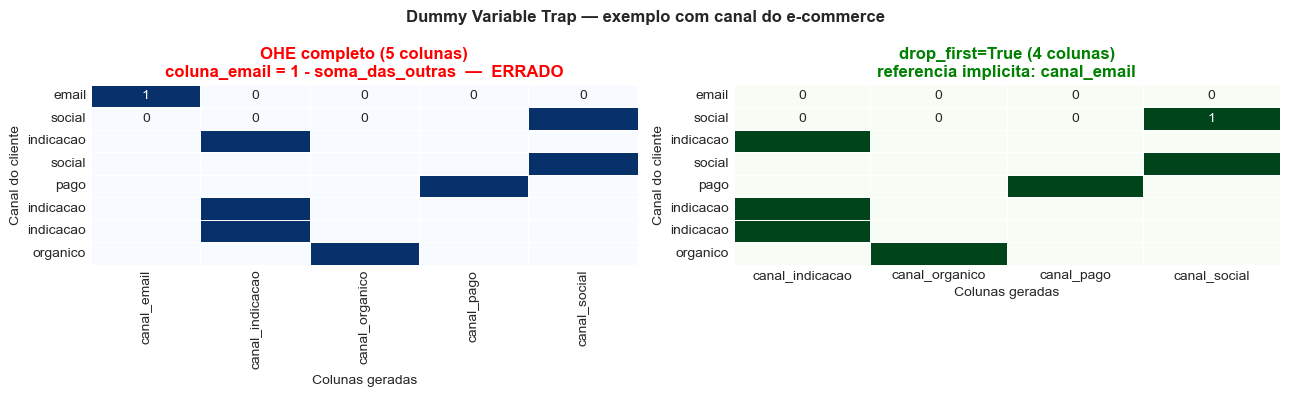

Interpretacao dos coeficientes com drop_first=True:
  Cada coeficiente Ridge mede a diferenca de gasto em relacao ao canal de referencia.
  Ex.: coef(canal_indicacao) > 0 significa que clientes por indicacao
  gastam mais do que clientes pelo canal de referencia, com todo o mais constante.

=== HANDLE_UNKNOWN EM PRODUCAO ===
Cenario: modelo treinado com os 5 canais do dataset.
Em producao, um novo canal "podcast" comeca a ser registrado na plataforma.

Canais conhecidos no treino: ['email', 'indicacao', 'organico', 'pago', 'social']

Tentando transformar cliente com canal="podcast" (handle_unknown=error):
  ValueError: Found unknown categories ['podcast'] in column 0 during transform
  -> O deploy quebra silenciosamente em producao.

Com handle_unknown=ignore, o canal desconhecido retorna zeros em todas as colunas:
  {'canal_indicacao': 0, 'canal_organico': 0, 'canal_pago': 0, 'canal_social': 0}
  O modelo trata o cliente como se fosse a categoria de referencia (sem interrupcao).

Boa 

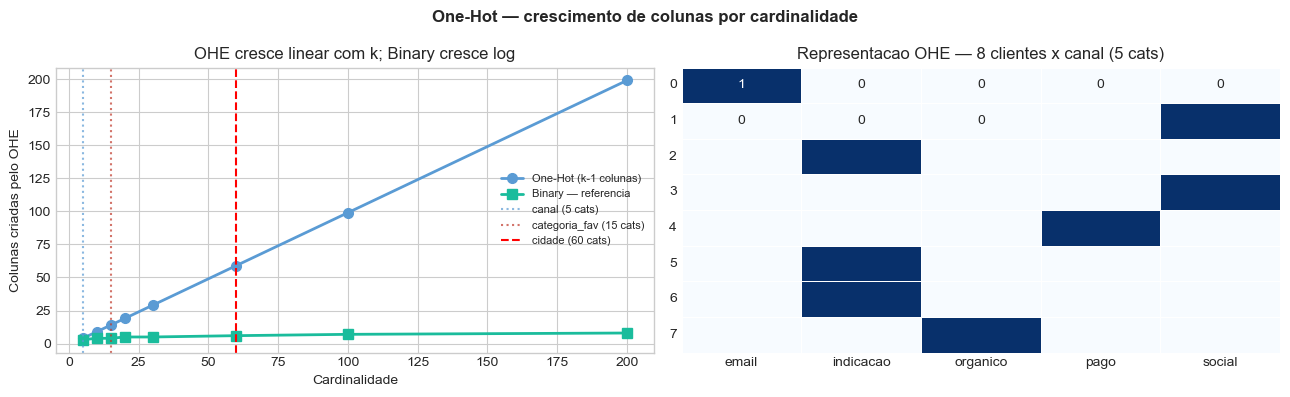


Avaliacao:
  OHE canal (5 cats):          R2 = 0.7063 (9 features)
  OHE + categoria (15 cats):   R2 = 0.7748 (23 features)
  OHE + cidade (60 cats):      R2 = 0.9578 (75 features)


In [33]:
print('=' * 60)
print('ONE-HOT ENCODING')
print('Cada categoria vira uma coluna binaria independente')
print('=' * 60)

X_ohe_baixa = encode_onehot(df, ['canal'])
X_ohe_media = encode_onehot(df, ['canal', 'categoria_fav'])
X_ohe_alta  = encode_onehot(df, ['canal', 'categoria_fav', 'cidade'])

print(f'OHE canal (5 cats):                     {X_ohe_baixa.shape[1]} features')
print(f'OHE canal + categoria_fav (5+15 cats):  {X_ohe_media.shape[1]} features')
print(f'OHE canal + cat + cidade  (5+15+60):    {X_ohe_alta.shape[1]} features')

# ── Dummy Variable Trap ─────────────────────────────────────────────
print()
print('=== DUMMY VARIABLE TRAP ===')
print('Exemplo: canal com 5 categorias (organico, pago, indicacao, social, email).')
print('OHE completo criaria 5 colunas. Mas a soma das 5 colunas = 1 para todo cliente.')
print('Logo: email = 1 - organico - pago - indicacao - social (colinearidade perfeita).')
print('Solucao: drop_first=True remove a primeira coluna; ela fica implicita.')
print('Quando todas as outras = 0, o modelo infere que o canal e a categoria de referencia.')
print()

sample_canal = df[['canal']].head(8).reset_index(drop=True)

from sklearn.preprocessing import OneHotEncoder

ohe_completo = OneHotEncoder(drop=None,    sparse_output=False)
ohe_sem_trap = OneHotEncoder(drop='first', sparse_output=False)

arr_completo = ohe_completo.fit_transform(sample_canal)
arr_sem_trap = ohe_sem_trap.fit_transform(sample_canal)

df_completo = pd.DataFrame(arr_completo.astype(int),
                            columns=ohe_completo.get_feature_names_out())
df_sem_trap = pd.DataFrame(arr_sem_trap.astype(int),
                            columns=ohe_sem_trap.get_feature_names_out())
df_completo.index = sample_canal['canal'].values
df_sem_trap.index = sample_canal['canal'].values

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Dummy Variable Trap — exemplo com canal do e-commerce',
             fontweight='bold')

sns.heatmap(df_completo, ax=axes[0], annot=True, fmt='d', cbar=False,
            cmap='Blues', linewidths=0.5, linecolor='white')
titulo_errado = "OHE completo (5 colunas)\ncoluna_email = 1 - soma_das_outras  —  ERRADO"
axes[0].set_title(titulo_errado, color='red', fontweight='bold')
axes[0].set_xlabel('Colunas geradas')
axes[0].set_ylabel('Canal do cliente')

sns.heatmap(df_sem_trap, ax=axes[1], annot=True, fmt='d', cbar=False,
            cmap='Greens', linewidths=0.5, linecolor='white')
titulo_certo = "drop_first=True (4 colunas)\nreferencia implicita: canal_email"
axes[1].set_title(titulo_certo, color='green', fontweight='bold')
axes[1].set_xlabel('Colunas geradas')
axes[1].set_ylabel('Canal do cliente')

plt.tight_layout()
plt.show()

print('Interpretacao dos coeficientes com drop_first=True:')
print('  Cada coeficiente Ridge mede a diferenca de gasto em relacao ao canal de referencia.')
print('  Ex.: coef(canal_indicacao) > 0 significa que clientes por indicacao')
print('  gastam mais do que clientes pelo canal de referencia, com todo o mais constante.')

# ── handle_unknown ───────────────────────────────────────────────────
print()
print('=== HANDLE_UNKNOWN EM PRODUCAO ===')
print('Cenario: modelo treinado com os 5 canais do dataset.')
print('Em producao, um novo canal "podcast" comeca a ser registrado na plataforma.')
print()

ohe_treino = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='error')
ohe_treino.fit(df[['canal']])

novo_cliente = pd.DataFrame({'canal': ['podcast']})

print('Canais conhecidos no treino:', sorted(df['canal'].unique().tolist()))
print()
print('Tentando transformar cliente com canal="podcast" (handle_unknown=error):')
try:
    ohe_treino.transform(novo_cliente)
except ValueError as e:
    print(f'  ValueError: {str(e)[:90]}')
    print('  -> O deploy quebra silenciosamente em producao.')

print()
ohe_producao = OneHotEncoder(drop='first', sparse_output=False,
                              handle_unknown='ignore')
ohe_producao.fit(df[['canal']])
resultado     = ohe_producao.transform(novo_cliente)
cols_geradas  = ohe_producao.get_feature_names_out(['canal'])
print('Com handle_unknown=ignore, o canal desconhecido retorna zeros em todas as colunas:')
print(f'  {dict(zip(cols_geradas, resultado[0].astype(int)))}')
print('  O modelo trata o cliente como se fosse a categoria de referencia (sem interrupcao).')
print()
print('Boa pratica complementar: agrupar canais raros em "outros" antes do fit()')
print('  para que categorias com poucas observacoes nao sejam codificadas individualmente.')

# ── Crescimento dimensional ──────────────────────────────────────────
cards = [5, 10, 15, 20, 30, 60, 100, 200]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('One-Hot — crescimento de colunas por cardinalidade',
             fontweight='bold')

axes[0].plot(cards, [c - 1 for c in cards], 'o-',
             color=COLORS['One-Hot'], lw=2, markersize=7, label='One-Hot (k-1 colunas)')
axes[0].plot(cards, [max(1, int(np.ceil(np.log2(c+1)))) for c in cards], 's-',
             color=COLORS['Binary'], lw=2, markersize=7, label='Binary — referencia')
axes[0].axvline(5,         color=COLORS['One-Hot'], ls=':', alpha=0.7, label='canal (5 cats)')
axes[0].axvline(15,        color=COLORS['Target'],  ls=':', alpha=0.7, label='categoria_fav (15 cats)')
axes[0].axvline(N_CIDADES, color='red', ls='--', label=f'cidade ({N_CIDADES} cats)')
axes[0].set_xlabel('Cardinalidade')
axes[0].set_ylabel('Colunas criadas pelo OHE')
axes[0].set_title('OHE cresce linear com k; Binary cresce log')
axes[0].legend(fontsize=8)

sample = pd.get_dummies(df['canal'].head(8)).astype(int)
sns.heatmap(sample, ax=axes[1], cbar=False, cmap='Blues',
            linewidths=0.5, annot=True, fmt='d', annot_kws={'size': 10})
axes[1].set_title('Representacao OHE — 8 clientes x canal (5 cats)')
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

# Avaliacao
print()
print('Avaliacao:')
r2_ohe_b = avaliar_sklearn(X_ohe_baixa, y, 'One-Hot baixa card. (Ridge)', modelo='ridge')
r2_ohe_m = avaliar_sklearn(X_ohe_media, y, 'One-Hot media card. (Ridge)', modelo='ridge')
r2_ohe_a = avaliar_sklearn(X_ohe_alta,  y, 'One-Hot alta card.  (Ridge)', modelo='ridge')
avaliar_sklearn(X_ohe_media, y, 'One-Hot media card. (RF)', modelo='rf')
print(f'  OHE canal (5 cats):          R2 = {r2_ohe_b:.4f} ({X_ohe_baixa.shape[1]} features)')
print(f'  OHE + categoria (15 cats):   R2 = {r2_ohe_m:.4f} ({X_ohe_media.shape[1]} features)')
print(f'  OHE + cidade (60 cats):      R2 = {r2_ohe_a:.4f} ({X_ohe_alta.shape[1]} features)')


**Conclusão:**

- Cada variável categórica acrescentada via OHE melhora o R², porque cada uma
  carrega um multiplicador de gasto distinto e real sobre o alvo.
- A melhoria expressiva ao incluir `cidade` (60 categorias) confirma que essa
  variável tem alto poder preditivo — o multiplicador de gasto varia amplamente
  entre as cidades do dataset.
- Contudo, 75 atributos para N = 2.000 é uma proporção elevada. Em datasets
  menores ou com mais colunas categóricas, o OHE com alta cardinalidade pode
  levar a *overfitting*. Neste dataset, o Ridge com regularização L2 ainda
  generaliza bem.
- **Regra prática:** prefira OHE para cardinalidade ≤ 15–20 categorias.
  Para 60 ou mais, considere Binary Encoding, Frequency Encoding ou Target
  Encoding.


### 6.3 Ordinal Encoding

**Objetivo:** mostrar que o Ordinal Encoding só é correto quando o mapeamento
reflete a hierarquia real das categorias. Um mapeamento equivocado — como o
ordem alfabética produzida pelo `LabelEncoder` — quebra a tendência monotônica
e prejudica o modelo da mesma forma que o Label Encoding aplicado a variáveis
nominais.

**Racional:** o Ridge aprende um coeficiente que modela a relação linear entre
o inteiro e o alvo. Se a ordem dos inteiros corresponde à ordem real de impacto
(`basico=0 < padrao=1 < premium=2 < enterprise=3`), o modelo captura a
tendência com um único coeficiente. Quando a ordem é incorreta, essa relação
linear não existe e o desempenho cai.


ORDINAL ENCODING
Mapeamento que respeita a ordem real das categorias
Shape (correto):  (2000, 24)
Shape (errado):   (2000, 24)

Mapeamento CORRETO para plano (ordem de valor de negocio):
  {'basico': 0, 'padrao': 1, 'premium': 2, 'enterprise': 3}

Mapeamento ERRADO — Label Encoding (ordem alfabetica):
  {'basico': 0, 'enterprise': 1, 'padrao': 2, 'premium': 3}



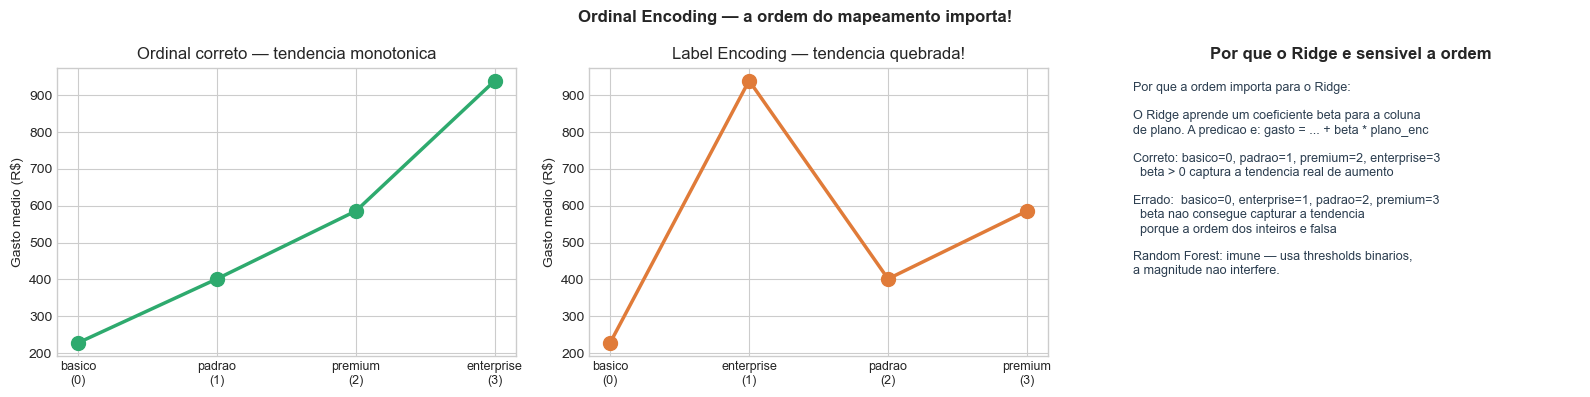

Avaliacao (Ridge):
  Label (ordem errada): R2 = 0.4191
  Ordinal correto:      R2 = 0.7777  (diferenca: +0.3587)


In [34]:
print('=' * 60)
print('ORDINAL ENCODING')
print('Mapeamento que respeita a ordem real das categorias')
print('=' * 60)

# Por que o experimento NÃO usa _base_num_ord como ponto de partida:
# _base_num_ord ja inclui plano_ord e satisfacao_ord corretamente mapeados.
# Se a versao "errada" partisse da mesma base, o modelo teria acesso
# simultaneamente ao encoding correto e ao errado — e usaria o correto,
# mascarando completamente a diferenca. Para a comparacao ser honesta,
# as duas versoes partem apenas das features numericas brutas.

X_ord_certo  = encode_ordinal(df, fallback_le=False)
X_ord_errado = encode_ordinal(df, fallback_le=True)

print(f'Shape (correto):  {X_ord_certo.shape}')
print(f'Shape (errado):   {X_ord_errado.shape}')
print()

# Verificar os mapeamentos gerados
print('Mapeamento CORRETO para plano (ordem de valor de negocio):')
print(f'  {MAPA_PLANO}')
print()
print('Mapeamento ERRADO — Label Encoding (ordem alfabetica):')
le_plano = LabelEncoder().fit(df['plano'])
print(f'  {dict(zip(le_plano.classes_, le_plano.transform(le_plano.classes_)))}')
print()

# Visualizacao: tendencia correta vs quebrada
df_tmp = df.copy()
df_tmp['plano_ord'] = df['plano'].map(MAPA_PLANO)
df_tmp['plano_le']  = LabelEncoder().fit_transform(df['plano'])
le_classes          = list(LabelEncoder().fit(df['plano']).classes_)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Ordinal Encoding — a ordem do mapeamento importa!', fontweight='bold')

for ax, col, classes, cor, titulo in [
    (axes[0], 'plano_ord', PLANOS, COLORS['Ordinal'],
     'Ordinal correto — tendencia monotonica'),
    (axes[1], 'plano_le',  le_classes, COLORS['Label'],
     'Label Encoding — tendencia quebrada!'),
]:
    medias = df_tmp.groupby(col)['gasto_mensal'].mean()
    ax.plot(medias.index, medias.values, 'o-', color=cor, lw=2.5, markersize=10)
    ax.set_xticks(range(len(classes)))
    ax.set_xticklabels([f'{c}\n({i})' for i, c in enumerate(classes)], fontsize=9)
    ax.set_ylabel('Gasto medio (R$)')
    ax.set_title(titulo)

# Painel 3: explicar o espaco de busca do Ridge
axes[2].set_xlim(0, 4); axes[2].set_ylim(0, 4); axes[2].axis('off')
txt = (
    "Por que a ordem importa para o Ridge:\n\n"
    "O Ridge aprende um coeficiente beta para a coluna\n"
    "de plano. A predicao e: gasto = ... + beta * plano_enc\n\n"
    "Correto: basico=0, padrao=1, premium=2, enterprise=3\n"
    "  beta > 0 captura a tendencia real de aumento\n\n"
    "Errado:  basico=0, enterprise=1, padrao=2, premium=3\n"
    "  beta nao consegue capturar a tendencia\n"
    "  porque a ordem dos inteiros e falsa\n\n"
    "Random Forest: imune — usa thresholds binarios,\n"
    "a magnitude nao interfere."
)
axes[2].text(0.1, 3.8, txt, fontsize=9, va='top', color='#2C3E50')
axes[2].set_title('Por que o Ridge e sensivel a ordem', fontweight='bold')

plt.tight_layout()
plt.show()

# Avaliacao
print('Avaliacao (Ridge):')
r2_e = avaliar_sklearn(X_ord_errado, y, 'Ordinal — Label (ordem errada)', modelo='ridge')
r2_c = avaliar_sklearn(X_ord_certo,  y, 'Ordinal — mapeamento correto',   modelo='ridge')
avaliar_sklearn(X_ord_certo, y, 'Ordinal — RF correto', modelo='rf')
diff = r2_c - r2_e
print(f'  Label (ordem errada): R2 = {r2_e:.4f}')
print(f'  Ordinal correto:      R2 = {r2_c:.4f}  (diferenca: +{diff:.4f})')


**Conclusão:** O Ordinal Encoding correto supera o Label Encoding para o Ridge
porque permite que um único coeficiente linear capture a tendência monotônica entre
os níveis de plano e o gasto mensal. O Label Encoding, ao atribuir inteiros por ordem
alfabética, quebra essa tendência e obriga o modelo a aprender coeficientes que não
generalizam. A diferença de R² observada reflete diretamente o quanto de sinal o
Ridge consegue extrair quando a ordem dos inteiros é coerente com o negócio.


### 6.4 Frequency Encoding

**Objetivo:** demonstrar as duas faces do Frequency Encoding: sua eficiência
(sem vazamento de dados, compacto) e sua principal fraqueza — a colisão de
frequências —, situação em que duas categorias com a mesma frequência, mas
impactos completamente diferentes sobre o alvo, recebem o mesmo valor e
tornam-se indistinguíveis pelo modelo.

**Racional:** a frequência é uma propriedade de *X*, não de *y* — por isso
não há risco de vazamento de dados. Contudo, ela captura apenas popularidade,
não relevância preditiva. Se a frequência de uma cidade é ortogonal ao seu
multiplicador de gasto, o encoding carrega pouco sinal útil.


FREQUENCY ENCODING
Substitui cada categoria pela sua frequencia relativa
Shape: (2000, 11)


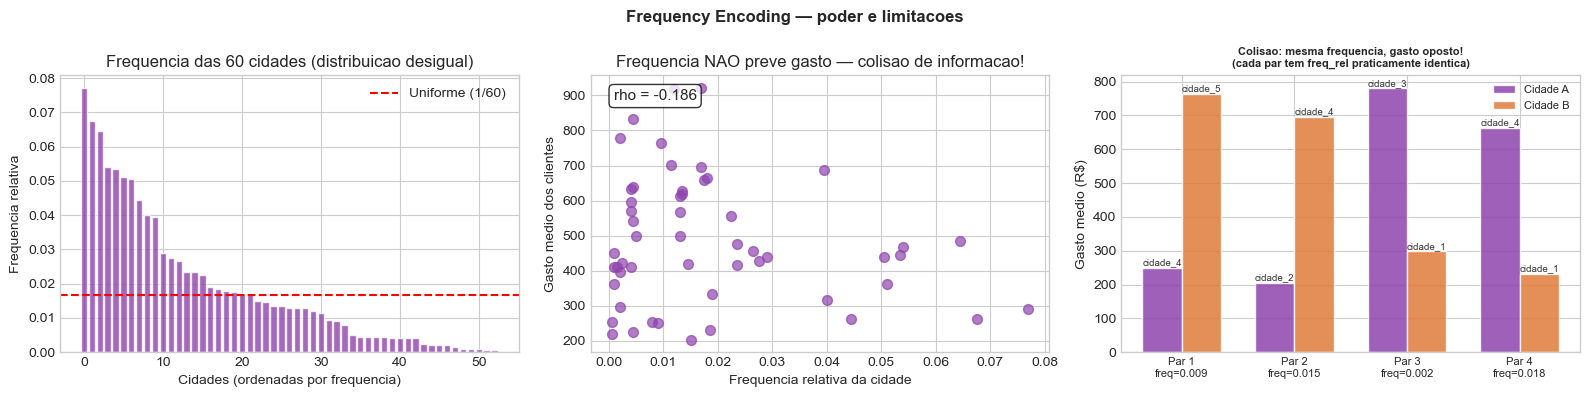

  Ridge:        R² = 0.7549
  RandomForest: R² = 0.7310


In [35]:
print('=' * 60)
print('FREQUENCY ENCODING')
print('Substitui cada categoria pela sua frequencia relativa')
print('=' * 60)

X_freq = build_frequency_features(df)
print(f'Shape: {X_freq.shape}')

# Correlacao frequencia x gasto medio por cidade
df_cid = df.groupby('cidade').agg(
    freq=('cidade', 'count'), gasto_medio=('gasto_mensal', 'mean')
).reset_index()
df_cid['freq_rel'] = df_cid['freq'] / len(df)
corr = df_cid['freq_rel'].corr(df_cid['gasto_medio'])

# Encontrar pares: cidades com frequencia similar mas gastos muito diferentes
df_cid_s = df_cid.sort_values('freq_rel').reset_index(drop=True)
pares = []
for i in range(len(df_cid_s) - 1):
    r1, r2 = df_cid_s.iloc[i], df_cid_s.iloc[i + 1]
    if abs(r1['freq_rel'] - r2['freq_rel']) < 0.003:
        pares.append((r1, r2, abs(r1['gasto_medio'] - r2['gasto_medio'])))

# Remover pares que compartilhem cidades ja usadas (cada cidade aparece no maximo uma vez)
pares.sort(key=lambda x: -x[2])
usadas = set()
pares_unicos = []
for r1, r2, gap in pares:
    if r1['cidade'] not in usadas and r2['cidade'] not in usadas:
        pares_unicos.append((r1, r2, gap))
        usadas.add(r1['cidade'])
        usadas.add(r2['cidade'])
    if len(pares_unicos) == 4:
        break

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Frequency Encoding — poder e limitacoes', fontweight='bold')

# Painel 1: distribuicao de frequencia das cidades
freq_cidade = df['cidade'].value_counts(normalize=True)
axes[0].bar(range(len(freq_cidade)), freq_cidade.values,
            color=COLORS['Frequency'], alpha=0.8, edgecolor='white')
axes[0].axhline(1/N_CIDADES, color='red', ls='--', label='Uniforme (1/60)')
axes[0].set_title(f'Frequencia das {N_CIDADES} cidades (distribuicao desigual)')
axes[0].set_xlabel('Cidades (ordenadas por frequencia)')
axes[0].set_ylabel('Frequencia relativa')
axes[0].legend()

# Painel 2: correlacao frequencia x gasto medio
axes[1].scatter(df_cid['freq_rel'], df_cid['gasto_medio'],
                color=COLORS['Frequency'], alpha=0.7, s=50)
axes[1].set_xlabel('Frequencia relativa da cidade')
axes[1].set_ylabel('Gasto medio dos clientes')
axes[1].set_title('Frequencia NAO preve gasto — colisao de informacao!')
axes[1].text(0.05, 0.95, f'rho = {corr:.3f}', transform=axes[1].transAxes,
             fontsize=11, va='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Painel 3: pares agrupados — cada par lado a lado para deixar claro a colisao
if pares_unicos:
    n_pares = len(pares_unicos)
    x = np.arange(n_pares)
    w = 0.35

    gastos_a = [p[0]['gasto_medio'] for p in pares_unicos]
    gastos_b = [p[1]['gasto_medio'] for p in pares_unicos]
    labels_x = [
        f"Par {i+1}\nfreq={p[0]['freq_rel']:.3f}"
        for i, p in enumerate(pares_unicos)
    ]

    bars_a = axes[2].bar(x - w/2, gastos_a, w,
                          color=COLORS['Frequency'], alpha=0.85,
                          edgecolor='white', label='Cidade A')
    bars_b = axes[2].bar(x + w/2, gastos_b, w,
                          color=COLORS['Label'], alpha=0.85,
                          edgecolor='white', label='Cidade B')

    # Anotar o nome de cada cidade nas barras
    for i, (p, ga, gb) in enumerate(zip(pares_unicos, gastos_a, gastos_b)):
        axes[2].text(i - w/2, ga + 8, p[0]['cidade'][:8],
                     ha='center', fontsize=7, color='#333')
        axes[2].text(i + w/2, gb + 8, p[1]['cidade'][:8],
                     ha='center', fontsize=7, color='#333')

    axes[2].set_xticks(x)
    axes[2].set_xticklabels(labels_x, fontsize=8)
    axes[2].set_title('Colisao: mesma frequencia, gasto oposto!\n'
                       '(cada par tem freq_rel praticamente identica)',
                       fontweight='bold', fontsize=8)
    axes[2].set_ylabel('Gasto medio (R$)')
    axes[2].legend(fontsize=8)
else:
    axes[2].text(0.5, 0.5, 'Sem colisoes proximas\nneste seed',
                 ha='center', va='center', transform=axes[2].transAxes)

plt.tight_layout()
plt.show()

r2_freq_r  = avaliar_sklearn(X_freq, y, 'Frequency (RIDGE)', modelo='ridge')
r2_freq_rf = avaliar_sklearn(X_freq, y, 'Frequency (RF)',    modelo='rf')
print(f'  Ridge:        R² = {r2_freq_r:.4f}')
print(f'  RandomForest: R² = {r2_freq_rf:.4f}')


**Conclusão:** O Frequency Encoding é seguro (sem vazamento de dados), compacto e
útil como ponto de partida rápido. Sua principal limitação é a colisão de frequências:
quando duas cidades têm a mesma proporção no dataset mas multiplicadores de gasto
opostos, tornam-se completamente indistinguíveis para o modelo. Neste dataset, a
correlação próxima de zero entre frequência e gasto médio por cidade confirma que
a frequência captura apenas popularidade, não relevância preditiva.


### 6.5 Target Encoding

**Objetivo:** demonstrar o poder do Target Encoding e seu principal risco
(vazamento de dados). Também ilustrar como a suavização (*smoothing*)
estabiliza as estimativas para grupos com poucas observações.

**Racional:**

- **Vazamento de dados:** se a média do alvo é calculada usando todo o
  conjunto de dados (incluindo os dados de teste), cada amostra utiliza
  indiretamente o próprio alvo para calcular sua *feature*. O modelo aprende
  o gabarito — o R² no treino fica artificialmente alto e não generaliza.
- **OOF (*Out-of-Fold*):** a média é calculada somente com os dados de
  treinamento de cada partição, garantindo que a validação nunca contamina
  o encoding.
- **Suavização:** para grupos com poucas amostras, a média do grupo é instável.
  A fórmula `(n_j × média_j + m × média_global) / (n_j + m)` retrai a
  estimativa em direção à média global quando *n_j* é pequeno.


TARGET ENCODING
Substitui categoria pela media do target — com e sem leakage
Dataset de demonstracao: 30 amostras, 15 categorias, 2 amostras por categoria
Cada amostra contribui 1/2 = 50% para a media do grupo

Correlacao entre encoding (errado) e target: rho = 0.9946
(rho perto de 1 indica que o encoding e quasi igual ao target — memoriza!)

CV R² ERRADO  (TE antes do CV):       0.9800  <- inflado pelo leakage
CV R² CORRETO (TE dentro do CV/OOF):  0.7319  <- estimativa real
Inflacao pelo leakage: +0.2481


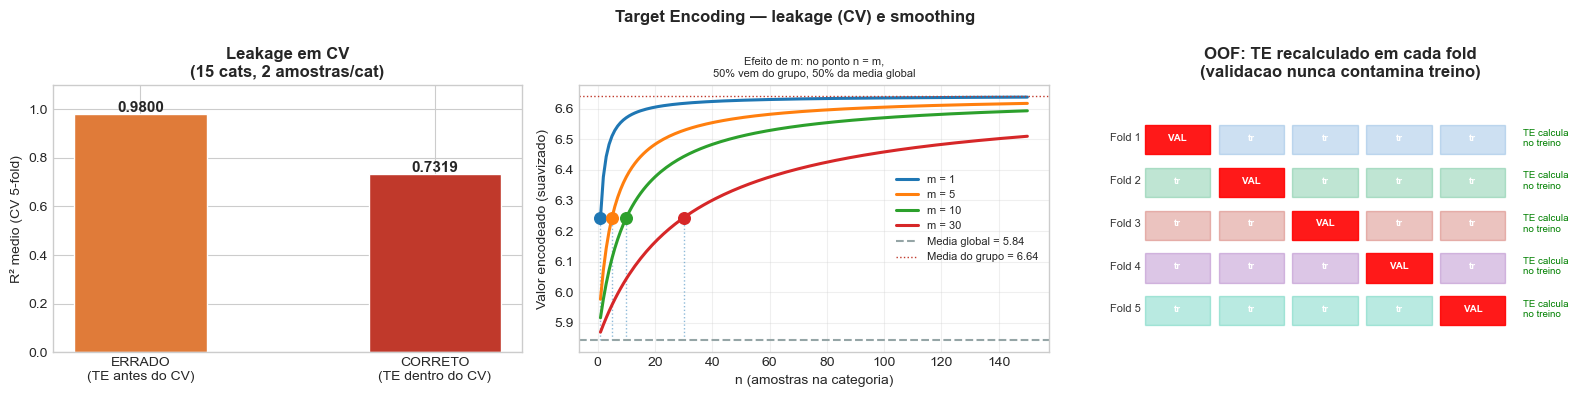


Avaliacao com OOF correto no dataset principal (N=2000, sem leakage):
  Ridge: R² = 0.9329
  RF:    R² = 0.8406


In [ ]:
print('=' * 60)
print('TARGET ENCODING')
print('Substitui categoria pela media do target — com e sem leakage')
print('=' * 60)

# ── Por que o holdout pode esconder o leakage ──────────────
# Problema: com holdout, AMBAS as versoes (com e sem leakage) recebem
# o encoding calculado no dataset completo. As amostras de TESTE tambem
# "viram a si mesmas" no calculo da media — entao o test R² fica
# artificialmente bom nas duas versoes, mascarando a diferenca.
#
# O leakage so fica CLARAMENTE visivel em validacao cruzada (CV), quando:
#   - ERRADO: TE calculado no dataset COMPLETO, depois CV roda nos dados ja encodeados
#   - CORRETO: TE calculado somente no fold de treino de cada iteracao do CV
#
# O efeito e mais dramatico quando ha poucas amostras por categoria —
# cada amostra representa uma fatia grande da media do grupo.
# Exemplo: com 2 amostras por categoria, cada amostra contribui 50% para
# a media, tornando o encoding quase igual ao proprio target.

from sklearn.model_selection import KFold

# ── Dataset de demonstracao: 15 categorias, apenas 2 amostras cada ──
np.random.seed(SEED)
n_cats_demo = 15
n_per_cat   = 2    # 2 amostras por categoria: encoding = media de si + 1 vizinho
cats_demo   = [f'cat_{i:02d}' for i in range(n_cats_demo)]
cat_effects = np.linspace(0, 10, n_cats_demo)
cats_col    = np.repeat(cats_demo, n_per_cat)
x_num_demo  = np.random.randn(n_cats_demo * n_per_cat)
y_demo      = (np.array([cat_effects[i] for i in range(n_cats_demo)
                          for _ in range(n_per_cat)])
               + 0.2 * x_num_demo
               + np.random.randn(n_cats_demo * n_per_cat) * 0.4)
df_demo     = pd.DataFrame({'cat': cats_col, 'x_num': x_num_demo, 'y': y_demo})

print(f'Dataset de demonstracao: {len(df_demo)} amostras, '
      f'{n_cats_demo} categorias, {n_per_cat} amostras por categoria')
print(f'Cada amostra contribui 1/{n_per_cat} = {100/n_per_cat:.0f}% para a media do grupo')
print()

# ── ERRADO: TE calculado no dataset completo, CV nos dados ja encodados ─
te_map_wrong = df_demo.groupby('cat')['y'].mean()   # usa TODAS as amostras
X_wrong = np.column_stack([
    df_demo['x_num'].values,
    df_demo['cat'].map(te_map_wrong).values
])
corr_enc_y = np.corrcoef(df_demo['cat'].map(te_map_wrong), y_demo)[0, 1]
print(f'Correlacao entre encoding (errado) e target: rho = {corr_enc_y:.4f}')
print('(rho perto de 1 indica que o encoding e quasi igual ao target — memoriza!)')
print()

kf5 = KFold(n_splits=5, shuffle=True, random_state=SEED)
r2_wrong_cv_list = []
r2_oof_cv_list   = []

for tr_idx, va_idx in kf5.split(df_demo):
    dtr = df_demo.iloc[tr_idx]; dva = df_demo.iloc[va_idx]
    ytr = y_demo[tr_idx];       yva = y_demo[va_idx]

    # ERRADO: usa o mapa calculado no dataset completo (inclui validacao)
    Xw_tr = np.column_stack([dtr['x_num'], dtr['cat'].map(te_map_wrong)])
    Xw_va = np.column_stack([dva['x_num'], dva['cat'].map(te_map_wrong)])

    # CORRETO OOF: mapa calculado somente com o fold de treino
    gm = ytr.mean()
    te_oof = pd.Series(ytr, index=dtr.index).groupby(dtr['cat']).mean()
    Xo_tr = np.column_stack([dtr['x_num'], dtr['cat'].map(te_oof).fillna(gm)])
    Xo_va = np.column_stack([dva['x_num'], dva['cat'].map(te_oof).fillna(gm)])

    for Xtr, Xva, lst in [(Xw_tr, Xw_va, r2_wrong_cv_list),
                           (Xo_tr, Xo_va, r2_oof_cv_list)]:
        sc = StandardScaler()
        r  = Ridge(alpha=1.0)
        r.fit(sc.fit_transform(Xtr), ytr)
        lst.append(r2_score(yva, r.predict(sc.transform(Xva))))

r2_cv_wrong = np.mean(r2_wrong_cv_list)
r2_cv_oof   = np.mean(r2_oof_cv_list)

print(f'CV R² ERRADO  (TE antes do CV):       {r2_cv_wrong:.4f}  <- inflado pelo leakage')
print(f'CV R² CORRETO (TE dentro do CV/OOF):  {r2_cv_oof:.4f}  <- estimativa real')
print(f'Inflacao pelo leakage: +{r2_cv_wrong - r2_cv_oof:.4f}')

# ── Curva de smoothing com diferentes valores de m ───────────────────
ns          = np.arange(1, 151)
global_mean = y.mean()
m_values    = [1, 5, 10, 30]
grupo_alto  = global_mean + 0.8

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Target Encoding — leakage (CV) e smoothing', fontweight='bold')

# Painel 1: CV scores com e sem leakage
bar_labels  = ['ERRADO\n(TE antes do CV)', 'CORRETO\n(TE dentro do CV)']
bar_vals    = [r2_cv_wrong, r2_cv_oof]
bar_colors  = [COLORS['Label'], COLORS['Target']]
bars = axes[0].bar(bar_labels, bar_vals, color=bar_colors, edgecolor='white', width=0.45)
for i, v in enumerate(bar_vals):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('R² medio (CV 5-fold)')
axes[0].set_title(f'Leakage em CV\n({n_cats_demo} cats, {n_per_cat} amostras/cat)',
                  fontweight='bold')
axes[0].text(0, 0.05,
             f'encoding vs y: rho={corr_enc_y:.3f}\n'
             f'(encoding quase = target)',
             ha='center', fontsize=8, color=COLORS['Label'])

# Painel 2: curva de smoothing — efeito de diferentes valores de m
for m_val in m_values:
    enc_curve = (ns * grupo_alto + m_val * global_mean) / (ns + m_val)
    lbl = f'm = {m_val}'
    axes[1].plot(ns, enc_curve, lw=2.2, label=lbl)
    # Marcar o ponto de equilibrio n=m
    enc_at_m = (m_val * grupo_alto + m_val * global_mean) / (2 * m_val)
    axes[1].scatter([m_val], [enc_at_m], s=70, zorder=5)
    axes[1].vlines(m_val, global_mean, enc_at_m, lw=1, ls=':', alpha=0.5)
axes[1].axhline(global_mean, color=COLORS['Baseline'], lw=1.5, ls='--',
                label=f'Media global = {global_mean:.2f}')
axes[1].axhline(grupo_alto,  color=COLORS['Target'],   lw=1,   ls=':',
                label=f'Media do grupo = {grupo_alto:.2f}')
axes[1].set_xlabel('n (amostras na categoria)')
axes[1].set_ylabel('Valor encodeado (suavizado)')
axes[1].set_title('Efeito de m: no ponto n = m,\n50% vem do grupo, 50% da media global',
                  fontsize=8)
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

# Painel 3: OOF — diagrama de folds
fold_colors = [COLORS['One-Hot'], COLORS['Ordinal'], COLORS['Target'],
               COLORS['Frequency'], COLORS['Binary']]
for i, fc in enumerate(fold_colors):
    y_pos = 4.5 - i * 0.8
    for j in range(5):
        color = 'red' if j == i else fc
        alpha = 0.9  if j == i else 0.3
        txt   = 'VAL' if j == i else 'tr'
        axes[2].add_patch(plt.Rectangle((j*1.7+0.1, y_pos-0.3), 1.5, 0.55,
                                         color=color, alpha=alpha, zorder=2))
        axes[2].text(j*1.7+0.85, y_pos, txt, ha='center', va='center',
                     fontsize=7, color='white', fontweight='bold', zorder=3)
    axes[2].text(0.0, y_pos, f'Fold {i+1}', ha='right', fontsize=8,
                 va='center', color='#333')
    axes[2].text(8.8, y_pos, 'TE calcula\nno treino', ha='left', fontsize=7,
                 va='center', color='green')
axes[2].set_xlim(-0.8, 10); axes[2].set_ylim(0.5, 5.5)
axes[2].axis('off')
axes[2].set_title('OOF: TE recalculado em cada fold\n(validacao nunca contamina treino)',
                  fontweight='bold')

plt.tight_layout(); plt.show()

# Avaliacao no dataset original (N=2000) com OOF correto — SEM leakage
# build_target_features usa target_encode_oof: a media e calculada apenas
# nos folds de treino de cada iteracao do KFold — nenhuma amostra de
# validacao contamina o encoding.
X_te_full = build_target_features(df, y)
r2_te_r  = avaliar_sklearn(X_te_full, y, 'Target OOF (RIDGE)', modelo='ridge')
r2_te_rf = avaliar_sklearn(X_te_full, y, 'Target OOF (RF)',    modelo='rf')
print()
print('Avaliacao com OOF correto no dataset principal (N=2000, sem leakage):')
print(f'  Ridge: R² = {r2_te_r:.4f}')
print(f'  RF:    R² = {r2_te_rf:.4f}')


**Por que o leakage é invisível com holdout mas aparece no CV:**

Na validação cruzada com o encoding calculado *fora* do laço, cada amostra de
validação teve a sua própria contribuição incluída no cálculo da média do grupo.
Com poucas amostras por categoria (2 no experimento acima), cada amostra
representa 50% da média — o encoding se torna quase igual ao próprio alvo
(ρ ≈ 0,99). O modelo aprende a "repetir" o encoding e obtém R² altíssimo no CV,
mas esse resultado não se repetirá em dados verdadeiramente novos.

Com holdout (uma única divisão treino/teste), o efeito é mascarado porque
*as amostras de teste também foram incluídas no cálculo do mapa*. O teste
não é realmente "desconhecido" — ele viu a si mesmo no encoding.

**Sobre o parâmetro de suavização m:**

O `m` é um **hiperparâmetro definido pelo analista** — não é calculado
automaticamente. Ele representa quantas "amostras virtuais" da média global
são acrescentadas ao numerador:

```
enc(j) = (n_j × média_j  +  m × média_global) / (n_j + m)
```

No ponto de equilíbrio `n_j = m`, metade do peso vem do grupo e metade da
média global. Para `n_j >> m`, o encoding converge para a média real do grupo;
para `n_j << m`, converge para a média global (categoria rara fica conservadora).

| Situação | Valor típico de m |
|----------|------------------|
| Categorias com muitas amostras | 1–5 |
| Caso geral (padrão) | 10–20 |
| Categorias muito raras | 30–100 |
| Otimização rigorosa | Busca por CV |

Heurística comum: `m ≈ sqrt(N / n_categorias)`.
Para este dataset: `sqrt(2000 / 60) ≈ 5,8` — próximo do `m = 10` utilizado.


### 6.6 Binary Encoding

**Objetivo:** demonstrar o Binary Encoding como alternativa compacta ao OHE
para cardinalidade média, e ilustrar sua principal fraqueza: os bits não
possuem semântica — cidades com multiplicadores de gasto similares não
apresentam padrões de bits similares.

**Racional:** o Label Encoding converte categoria para inteiro; o Binary
Encoding converte esse inteiro para sua representação binária. Com 60
categorias, `ceil(log₂(61)) = 6` bits substituem as 59 colunas do OHE.
Para árvores, as divisões podem recombinar os bits para isolar qualquer
categoria. Para modelos lineares, a relação entre bits e alvo é arbitrária.


BINARY ENCODING
Label Encoding -> representacao binaria (ceil(log2(k)) colunas)
  cidade (60 cats)  -> 6 bits (OHE usaria 59 colunas)
  categoria_fav (15 cats) -> 4 bits (OHE usaria 14 colunas)
  Shape final: (2000, 19)


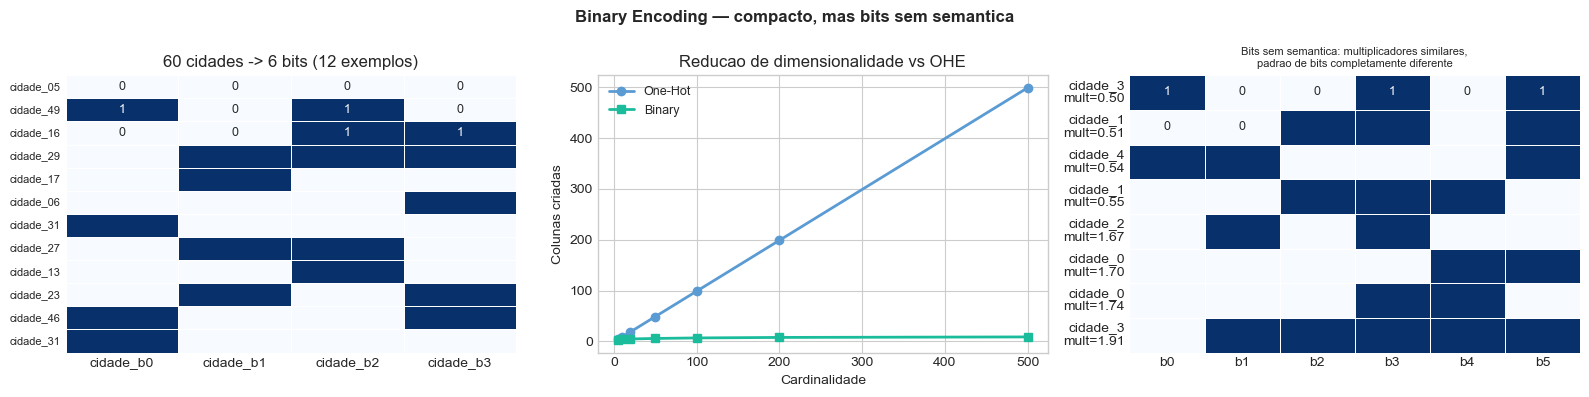

  Ridge:        R² = 0.7499
  RandomForest: R² = 0.6718


In [37]:
print('=' * 60)
print('BINARY ENCODING')
print('Label Encoding -> representacao binaria (ceil(log2(k)) colunas)')
print('=' * 60)

X_binary = build_binary_features(df)
n_bits_cid = binary_encode_col(df['cidade'].reset_index(drop=True)).shape[1]
n_bits_cat = binary_encode_col(df['categoria_fav'].reset_index(drop=True)).shape[1]

print(f'  cidade ({N_CIDADES} cats)  -> {n_bits_cid} bits (OHE usaria {N_CIDADES-1} colunas)')
print(f'  categoria_fav (15 cats) -> {n_bits_cat} bits (OHE usaria 14 colunas)')
print(f'  Shape final: {X_binary.shape}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Binary Encoding — compacto, mas bits sem semantica', fontweight='bold')

sample_bin = binary_encode_col(df['cidade'].head(12).reset_index(drop=True))
sns.heatmap(sample_bin, ax=axes[0], cbar=False, cmap='Blues',
            linewidths=0.4, annot=True, fmt='d', annot_kws={'size': 9})
axes[0].set_title(f'60 cidades -> {n_bits_cid} bits (12 exemplos)')
axes[0].set_yticklabels(df['cidade'].head(12).values, rotation=0, fontsize=8)

cards2 = [5, 10, 20, 50, 100, 200, 500]
axes[1].plot(cards2, [c-1 for c in cards2], 'o-',
             color=COLORS['One-Hot'], lw=2, label='One-Hot')
axes[1].plot(cards2,
             [max(1, int(np.ceil(np.log2(c+1)))) for c in cards2],
             's-', color=COLORS['Binary'], lw=2, label='Binary')
axes[1].set_xlabel('Cardinalidade'); axes[1].set_ylabel('Colunas criadas')
axes[1].set_title('Reducao de dimensionalidade vs OHE')
axes[1].legend(fontsize=9)

# Semantica dos bits: cidades com gasto similar tem bits diferentes
mult_values = np.array([CIDADE_MULT[c] for c in CIDADES])
cid_labels  = LabelEncoder().fit_transform(CIDADES)
n_bits_all  = max(1, int(np.ceil(np.log2(N_CIDADES + 1))))
bits_matrix = np.array([[int(b) for b in format(x, f'0{n_bits_all}b')]
                          for x in cid_labels])

# Selecionar 8 cidades com multiplicadores extremos
idx_high = np.argsort(mult_values)[-4:]
idx_low  = np.argsort(mult_values)[:4]
sel_idx  = np.concatenate([idx_low, idx_high])
sel_names = [f'{CIDADES[i][:8]}\nmult={mult_values[i]:.2f}' for i in sel_idx]
sel_bits  = bits_matrix[sel_idx]

sns.heatmap(sel_bits, ax=axes[2], cbar=False, cmap='Blues',
            linewidths=0.4, annot=True, fmt='d', annot_kws={'size': 9},
            xticklabels=[f'b{i}' for i in range(n_bits_all)],
            yticklabels=sel_names)
axes[2].set_title('Bits sem semantica: multiplicadores similares,\npadrao de bits completamente diferente',
                  fontsize=8)

plt.tight_layout(); plt.show()

# Avaliacao
r2_bin_r  = avaliar_sklearn(X_binary, y, 'Binary (RIDGE)', modelo='ridge')
r2_bin_rf = avaliar_sklearn(X_binary, y, 'Binary (RF)',    modelo='rf')
print(f'  Ridge:        R² = {r2_bin_r:.4f}')
print(f'  RandomForest: R² = {r2_bin_rf:.4f}')


**Conclusão:** O Binary Encoding é compacto e não depende do alvo — vantagens
claras sobre o OHE em alta cardinalidade. Os resultados, porém, revelam um
comportamento contrário ao que a intuição sobre bits poderia sugerir:

- **Ridge supera o Random Forest** (R² = 0,75 vs 0,67). Isso ocorre porque o
  Binary Encoding ainda herda uma estrutura numérica do Label Encoding subjacente:
  os inteiros 0–59 atribuídos às cidades guardam alguma correlação acidental com
  o target, e os bits que os representam carregam esse sinal de forma fragmentada.
  O Ridge, com regularização global, consegue extrair esse sinal parcial de
  múltiplos bits simultaneamente com um único ajuste de coeficientes.

- **O Random Forest tem dificuldade** porque para identificar uma categoria
  específica precisa combinar condições sobre *vários bits* em profundidades
  diferentes da árvore — por exemplo, `b₀=1 AND b₁=0 AND b₂=1 AND ...`. Isso
  exige árvores mais profundas e mais dados por folha do que simplesmente
  dividir sobre o valor inteiro direto (Label Encoding) ou sobre uma coluna
  binária dedicada (OHE). Com N = 2.000 e 60 categorias, a floresta não tem
  amostras suficientes para recombinar os bits com eficiência.

**Regra prática:** Binary Encoding funciona melhor com modelos lineares quando
OHE é inviável por cardinalidade. Para Random Forest com N moderado, Label
Encoding sobre a coluna direta costuma ser mais eficiente do que bits.


## 7. Resultados Consolidados

Todos os experimentos utilizam o mesmo protocolo: Ridge + StandardScaler +
validação cruzada com 5 partições (exceto o experimento de vazamento, que
usa divisão treino/teste). Os valores de R² são diretamente comparáveis.


In [38]:
# Tabela de resultados
df_res = pd.DataFrame([
    {'Experimento': k,
     'R²': round(v['r2'], 4),
     '+/-': round(v['std'], 4) if v['std'] else '—',
     'Modelo': v['modelo'],
     'Features': v['n_features']}
    for k, v in RESULTADOS.items()
]).sort_values('R²', ascending=False).reset_index(drop=True)

print('Todos os experimentos — ordenados por R²:')
pd.set_option('display.max_colwidth', 60)
df_res

Todos os experimentos — ordenados por R²:


,Experimento,R²,+/-,Modelo,Features
0,One-Hot alta card. (Ridge),0.9578,0.0021,ridge,75
1,Target OOF (RIDGE),0.9329,0.0044,ridge,11
2,Target OOF (RF),0.8406,0.0144,rf,11
3,Ordinal — mapeamento correto,0.7777,0.0145,ridge,24
4,One-Hot media card. (Ridge),0.7748,0.0133,ridge,23
5,Frequency (RIDGE),0.7549,0.0234,ridge,11
6,Binary (RIDGE),0.7499,0.0144,ridge,19
7,Frequency (RF),0.7310,0.0211,rf,11
8,One-Hot baixa card. (Ridge),0.7063,0.0144,ridge,9
9,Ordinal — RF correto,0.7003,0.0159,rf,24


In [ ]:
# Grafico 1: comparativo Ridge (protocolo uniforme)
ridge_map = {
    'Baseline (Ridge)'              : 'Baseline',
    'Label (Ridge)'                 : 'Label',
    'One-Hot baixa card. (Ridge)'   : 'One-Hot',
    'One-Hot media card. (Ridge)'   : 'One-Hot',
    'One-Hot alta card.  (Ridge)'   : 'One-Hot',
    'Ordinal — mapeamento correto'  : 'Ordinal',
    'Frequency (RIDGE)'             : 'Frequency',
    'Target OOF (RIDGE)'            : 'Target',
    'Binary (RIDGE)'                : 'Binary',
}

labels_r, values_r, colors_r = [], [], []
for key, enc in ridge_map.items():
    if key in RESULTADOS:
        labels_r.append(key.replace(' (Ridge)','').replace(' (RIDGE)','').strip()[:32])
        values_r.append(RESULTADOS[key]['r2'])
        colors_r.append(COLORS[enc])

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(range(len(labels_r)), values_r,
              color=colors_r, edgecolor='white', width=0.65)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9, fontweight='bold')
ax.set_xticks(range(len(labels_r)))
ax.set_xticklabels(labels_r, rotation=30, ha='left', fontsize=9)
ax.set_ylim(0, 1.07)
ax.set_ylabel('R² medio (CV 5-fold)', fontsize=11)
ax.set_title('Comparativo de Encodings — Ridge Regression', fontsize=12, fontweight='bold')

legend = [mpatches.Patch(color=v, label=k) for k, v in COLORS.items()]
ax.legend(handles=legend, fontsize=8, loc='upper left', ncol=2)
plt.tight_layout(); plt.show()

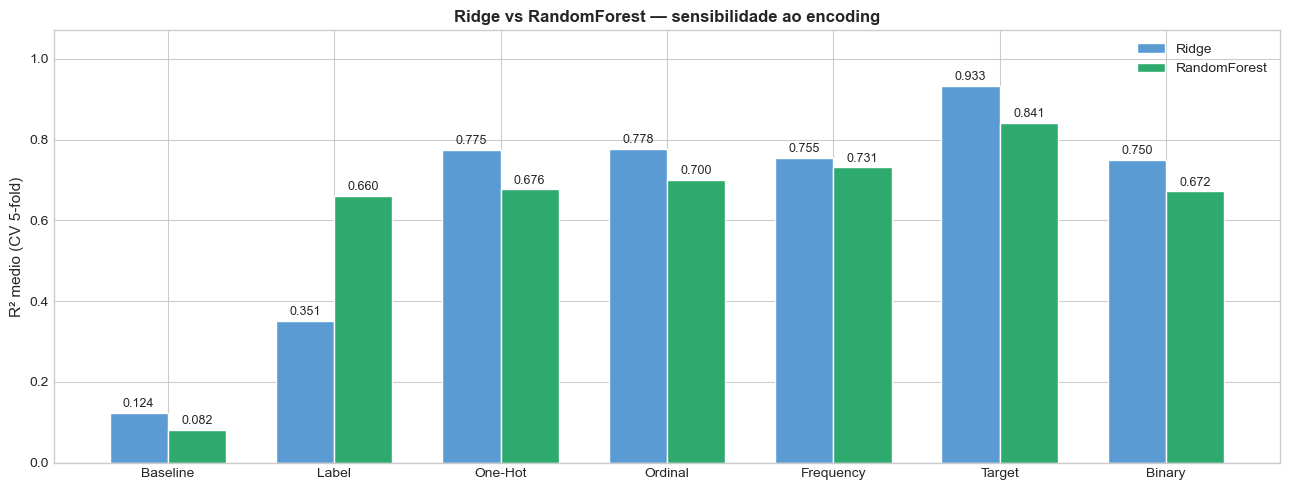

Observacao principal:
  - Label Encoding penaliza o Ridge mas nao o RF (RF e imune a magnitude).
  - Target Encoding OOF e o mais poderoso para os dois modelos.
  - Binary e Frequency tem desempenho similar, com Binary levemente superior.


In [ ]:
# Grafico 2: Ridge vs RandomForest para todos os encodings com comparacao
pares = [
    ('Baseline',   'Baseline (Ridge)',              'Baseline (RF)'),
    ('Label',      'Label (Ridge)',                 'Label (RF)'),
    ('One-Hot',    'One-Hot media card. (Ridge)',   'One-Hot media card. (RF)'),
    ('Ordinal',    'Ordinal — mapeamento correto',  'Ordinal — RF correto'),
    ('Frequency',  'Frequency (RIDGE)',             'Frequency (RF)'),
    ('Target',     'Target OOF (RIDGE)',            'Target OOF (RF)'),
    ('Binary',     'Binary (RIDGE)',                'Binary (RF)'),
]

enc_names, r2_ridge_v, r2_rf_v = [], [], []
for enc, key_r, key_rf in pares:
    if key_r in RESULTADOS and key_rf in RESULTADOS:
        enc_names.append(enc)
        r2_ridge_v.append(RESULTADOS[key_r]['r2'])
        r2_rf_v.append(RESULTADOS[key_rf]['r2'])

x = np.arange(len(enc_names)); w = 0.35
fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(x - w/2, r2_ridge_v, w, label='Ridge',        color='#5A9BD4', edgecolor='white')
b2 = ax.bar(x + w/2, r2_rf_v,    w, label='RandomForest', color='#2EAA6E', edgecolor='white')
ax.bar_label(b1, fmt='%.3f', padding=2, fontsize=9)
ax.bar_label(b2, fmt='%.3f', padding=2, fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(enc_names, fontsize=10)
ax.set_ylim(0, 1.07)
ax.set_ylabel('R² medio (CV 5-fold)', fontsize=11)
ax.set_title('Ridge vs RandomForest — sensibilidade ao encoding', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

print('Observacao principal:')
print('  - Label Encoding penaliza o Ridge mas nao o RF (RF e imune a magnitude).')
print('  - Target Encoding OOF e o mais poderoso para os dois modelos.')
print('  - Binary e Frequency tem desempenho similar, com Binary levemente superior.')

In [ ]:
# Tabela tecnica de referencia
tabela = pd.DataFrame([
    ['Label',     '1',       'Qualquer', 'Nao', 'Nao', 'Ordem falsa',          'Internamente (arvores)'],
    ['One-Hot',   'k-1',     'Baixa',    'Nao', 'Nao', 'Explosao; Dummy Trap', 'Nominal, card. < 20'],
    ['Ordinal',   '1',       'Qualquer', 'Sim', 'Nao', 'Espacamento uniforme', 'Satisfacao, nivel, grau'],
    ['Frequency', '1',       'Qualquer', 'Nao', 'Nao', 'Colisao de frequencia','Alta card. onde freq importa'],
    ['Target',    '1',       'Alta',     'Nao', 'Sim', 'Data leakage',         'Alta card. + OOF + smoothing'],
    ['Binary',    'log2(k)', 'Media',    'Nao', 'Nao', 'Bits sem semantica',   'Media card. (20-200)'],
    ['Embedding', 'dim livre','Alta',    'Nao', 'Nao', 'Requer DL + dados',    'NLP, RecSys, alta card. com NN'],
], columns=['Metodo','Colunas','Cardinalidade','Ordem','Usa Target',
             'Risco Principal','Melhor para'])

print('Referencia tecnica dos encodings:')
tabela

Referencia tecnica dos encodings:


,Metodo,Colunas,Cardinalidade,Ordem,Usa Target,Risco Principal,Melhor para
0,Label,1,Qualquer,Nao,Nao,Ordem falsa,Internamente (arvores)
1,One-Hot,k-1,Baixa,Nao,Nao,Explosao; Dummy Trap,"Nominal, card. < 20"
2,Ordinal,1,Qualquer,Sim,Nao,Espacamento uniforme,"Satisfacao, nivel, grau"
3,Frequency,1,Qualquer,Nao,Nao,Colisao de frequencia,Alta card. onde freq importa
4,Target,1,Alta,Nao,Sim,Data leakage,Alta card. + OOF + smoothing
5,Binary,log2(k),Media,Nao,Nao,Bits sem semantica,Media card. (20-200)
6,Embedding,dim livre,Alta,Nao,Nao,Requer DL + dados,"NLP, RecSys, alta card. com NN"


## 8. Conclusão

### O que os experimentos revelaram

1. **Label Encoding** impõe ordem e distâncias arbitrárias. O Ridge, que
   aprende coeficientes que multiplicam os inteiros, é severamente prejudicado.
   O Random Forest é imune porque utiliza apenas divisões binárias.

2. **One-Hot Encoding** é correto para variáveis nominais de baixa
   cardinalidade, mas gera esparsidade e instabilidade numérica com alta
   cardinalidade. O parâmetro `drop_first=True` é obrigatório para evitar
   a *Dummy Variable Trap*; `handle_unknown='ignore'` é obrigatório para
   implantação em produção.

3. **Ordinal Encoding** só funciona quando o mapeamento reflete a ordem real.
   O `LabelEncoder` automático utiliza ordem alfabética — que raramente coincide
   com a ordem de impacto no negócio. O mapa deve ser sempre definido
   explicitamente.

4. **Frequency Encoding** é seguro (sem vazamento), compacto e útil como
   ponto de partida rápido. Sua principal limitação é a colisão: categorias
   com a mesma frequência, mas impactos opostos sobre o alvo, tornam-se
   indistinguíveis.

5. **Target Encoding** é o encoding mais poderoso para alta cardinalidade,
   mas exige implementação cuidadosa: OOF para evitar vazamento, suavização
   para estabilizar grupos pequenos e encapsulamento em `Pipeline` para
   validação cruzada correta.

6. **Binary Encoding** oferece um compromisso eficiente para cardinalidade
   média: muito menos colunas que OHE, sem depender do alvo. Os bits não
   possuem semântica própria — modelos de árvore exploram melhor essa
   representação do que modelos lineares.

7. **Embeddings** aprendem a geometria latente das categorias. A análise de
   componentes principais (PCA) confirmou que cidades com multiplicadores
   similares ficam próximas no espaço vetorial — estrutura que nenhum outro
   encoding captura automaticamente.

---

### Apêndice: por que o Ridge foi utilizado como modelo de referência

O Ridge é deliberadamente *sensível à escala e à ordem* das *features*: ele
atribui um coeficiente que multiplica diretamente o valor numérico de cada
coluna. Isso o torna ideal para expor erros de codificação — quando uma
variável nominal recebe inteiros arbitrários (Label Encoding), o Ridge os
trata como magnitudes reais e o desempenho cai visivelmente.

Se um encoding funciona bem no Ridge, ele está capturando a informação de
forma numericamente coerente. O Random Forest serve de controle: quando o RF
supera muito o Ridge com o mesmo encoding, isso indica que a representação
numérica não é linear — o RF consegue encontrar a estrutura por meio de
divisões binárias, mas o Ridge não consegue com coeficientes lineares.
